In [1]:
# Cell 1: Install dependencies
# ─────────────────────────────────────────────────────────────────────────────
# Core libraries for dataset loading, fine-tuning, and evaluation.
# PySastrawi : Indonesian stemmer (used during preprocessing)
# emoji      : converts Unicode emoji to descriptive text tokens
!pip install -q \
    "datasets>=2.21.0" \
    "pyarrow>=14.0.1" \
    "transformers>=4.40.0" \
    "accelerate>=0.30.0" \
    seaborn \
    scikit-learn \
    PySastrawi \
    emoji


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 3.7 MB/s eta 0:00:00a 0:00:01


In [2]:
# Cell 2: Imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import copy
import math
import glob
import warnings
import inspect
from dataclasses import dataclass
from typing import Any, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score as sk_f1,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    TrainerCallback,
    EvalPrediction,
    EarlyStoppingCallback,
)

warnings.filterwarnings("ignore")
print("✓ Imports done.")


✓ Imports done.


In [3]:
# Cell 3: Device detection
# ─────────────────────────────────────────────────────────────────────────────
def get_device():
    try:
        import torch_xla.core.xla_model as xm
        device = xm.xla_device()
        print(f"Device   : TPU  ({device})")
        return device, "tpu"
    except ImportError:
        pass

    if torch.cuda.is_available():
        device   = torch.device("cuda")
        gpu_name = torch.cuda.get_device_name(0)
        try:
            _ = torch.zeros(1, device=device) + torch.zeros(1, device=device)
            torch.cuda.synchronize()
            cap = torch.cuda.get_device_capability(0)
            print(f"Device   : {device}")
            print(f"GPU      : {gpu_name}")
            print(f"Compute  : sm_{cap[0]}{cap[1]}")
            print(f"PyTorch  : {torch.__version__}")
            print(f"CUDA     : {torch.version.cuda}")
            return device, "gpu"
        except (RuntimeError, Exception) as e:
            warnings.warn(f"GPU '{gpu_name}' detected but incompatible. Falling back to CPU.",
                          RuntimeWarning, stacklevel=2)

    device = torch.device("cpu")
    print("Device   : CPU (training will be slow)")
    return device, "cpu"


print(f"PyTorch  : {torch.__version__}")
DEVICE, DEVICE_TYPE = get_device()

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
COLORS = {
    "Teacher"                : "#4C72B0",
    "Self-Distilled Teacher" : "#8172B2",
    "Student no KD"          : "#DD8452",
    "Student with KD"        : "#55A868",
}


PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4
Compute  : sm_75
PyTorch  : 2.10.0+cu128
CUDA     : 12.8


In [4]:
# Cell 4: Hyperparameters & global configuration
# ─────────────────────────────────────────────────────────────────────────────
# Teacher : indobenchmark/indobert-base-p1
#   → IndoBERT pre-trained on large Indonesian corpus
#   → https://huggingface.co/indobenchmark/indobert-base-p1
#
# Student : distilbert-base-multilingual-cased
#   → 6-layer multilingual DistilBERT; ~40% fewer parameters than BERT-base

# ── Model identifiers ─────────────────────────────────────────────────────────
TEACHER_NAME     = "indobenchmark/indobert-base-p1"
STUDENT_NAME     = "distilbert-base-multilingual-cased"
MAX_LENGTH       = 128

# ── Training hyperparameters ──────────────────────────────────────────────────
TEACHER_LR       = 2e-5
STUDENT_LR       = 3e-5
NUM_EPOCHS       = 5
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE  = 32
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.1

# ── Early stopping ────────────────────────────────────────────────────────────
EARLY_STOPPING_PATIENCE = 2

# ── Self-distillation ─────────────────────────────────────────────────────────
SD_TEMPERATURE       = 4
SD_ALPHA             = 0.7
TEACHER_F1_THRESHOLD = 0.80

# ── ALM-KD core loss weights ──────────────────────────────────────────────────
ALM_ALPHA       = 0.5
ALM_BETA        = 0.2
ALM_TEMPERATURE = 2.0
ALM_GAMMA       = 0.1
ALM_DELTA       = 0.1
ALM_ETA         = 0.05

# ── Dynamic alpha scheduling ──────────────────────────────────────────────────
ALM_ALPHA_END     = 0.2
USE_DYNAMIC_ALPHA = True

# ── Label smoothing ───────────────────────────────────────────────────────────
LABEL_SMOOTHING = 0.1

# ── Class weighting ───────────────────────────────────────────────────────────
USE_CLASS_WEIGHT = True   # enabled: train imbalance ratio is 5.62x

# ── Dataset split ratios (used if dataset has no predefined splits) ───────────
# If your CSV already has a 'split' column with 'train'/'val'/'test' values,
# set MANUAL_SPLIT = False. Otherwise set True to auto-split.
MANUAL_SPLIT      = True   # Re-splitting from scratch: test set had masked labels
TRAIN_RATIO       = 0.80
VAL_RATIO         = 0.10
# TEST_RATIO is inferred as 1 - TRAIN_RATIO - VAL_RATIO
RANDOM_SEED       = 42

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Reinitialize device after restricting visibility
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded.")
print(f"  Teacher model        : {TEACHER_NAME}")
print(f"  Student model        : {STUDENT_NAME}")
print(f"  Dynamic alpha        : {USE_DYNAMIC_ALPHA} ({ALM_ALPHA} → {ALM_ALPHA_END})")
print(f"  Label smoothing      : {LABEL_SMOOTHING}")
print(f"  Weight decay (L2)    : {WEIGHT_DECAY}")
print(f"  Early stopping       : patience={EARLY_STOPPING_PATIENCE}")
print(f"  PKD weight (δ)       : {ALM_DELTA}")
print(f"  Attn weight (η)      : {ALM_ETA}")


Configuration loaded.
  Teacher model        : indobenchmark/indobert-base-p1
  Student model        : distilbert-base-multilingual-cased
  Dynamic alpha        : True (0.5 → 0.2)
  Label smoothing      : 0.1
  Weight decay (L2)    : 0.01
  Early stopping       : patience=2
  PKD weight (δ)       : 0.1
  Attn weight (η)      : 0.05


In [5]:
# Cell 5: Load dataset — alvinhanafie/dataset-for-indonesian-sentiment-analysis
# ─────────────────────────────────────────────────────────────────────────────
# The original test split (test_preprocess_masked_label.tsv) has all labels
# masked as "neutral", making it useless for evaluation.
# We load all three TSV files, combine them into one pool, then re-split
# properly with stratification in Cell 9.

INPUT_DIR = "/kaggle/input"

all_files = (
    glob.glob(os.path.join(INPUT_DIR, "**/*.tsv"), recursive=True) +
    glob.glob(os.path.join(INPUT_DIR, "**/*.csv"), recursive=True)
)
print(f"Files found: {all_files}")
assert len(all_files) > 0, "No TSV/CSV files found in /kaggle/input. Make sure the dataset is attached."

def read_file(path: str) -> pd.DataFrame:
    sep = "\t" if path.endswith(".tsv") else ","
    return pd.read_csv(path, sep=sep)

# Load and tag each file so we can see where data came from
dfs = []
for f in all_files:
    df_part = read_file(f)
    df_part["_source"] = os.path.basename(f)
    dfs.append(df_part)
    print(f"  Loaded {os.path.basename(f)}: {len(df_part)} rows, columns={df_part.columns.tolist()}")

# Combine everything into one pool — re-splitting happens in Cell 9
df_raw = pd.concat(dfs, ignore_index=True)
df_raw = df_raw.drop(columns=["_source"], errors="ignore")

print(f"\nCombined shape : {df_raw.shape}")
print(f"Columns        : {df_raw.columns.tolist()}")
print(f"\nSample (first 3 rows):")
print(df_raw.head(3))
print(f"\nNull values:\n{df_raw.isnull().sum()}")

# has_presplit=False because we are intentionally re-splitting from scratch
has_presplit = False
df_splits    = None


Files found: ['/kaggle/input/datasets/alvinhanafie/dataset-for-indonesian-sentiment-analysis/train_preprocess_ori.tsv', '/kaggle/input/datasets/alvinhanafie/dataset-for-indonesian-sentiment-analysis/valid_preprocess.tsv', '/kaggle/input/datasets/alvinhanafie/dataset-for-indonesian-sentiment-analysis/test_preprocess_masked_label.tsv']
  Loaded train_preprocess_ori.tsv: 11000 rows, columns=['text', 'sentiment', '_source']
  Loaded valid_preprocess.tsv: 1260 rows, columns=['text', 'sentiment', '_source']
  Loaded test_preprocess_masked_label.tsv: 500 rows, columns=['text', 'sentiment', '_source']

Combined shape : (12760, 2)
Columns        : ['text', 'sentiment']

Sample (first 3 rows):
                                                text sentiment
0  warung ini dimiliki oleh pengusaha pabrik tahu...  positive
1  mohon ulama lurus dan k212 mmbri hujjah partai...   neutral
2  lokasi strategis di jalan sumatera bandung . t...  positive

Null values:
text         0
sentiment    0
dtype: int6

In [6]:
# Cell 6: Auto-detect text and label columns
# ─────────────────────────────────────────────────────────────────────────────
# ── MANUAL OVERRIDE ───────────────────────────────────────────────────────────
# If auto-detection is wrong, uncomment and fill in manually:
# TEXT_COL_RAW  = "Tweet"       # Name of the text column in your CSV
# LABEL_COL_RAW = "label"       # Name of the label column in your CSV
# ─────────────────────────────────────────────────────────────────────────────

# Candidate column names for text and label
_TEXT_CANDIDATES  = ["text", "Text", "review", "Review", "tweet", "Tweet",
                     "kalimat", "Kalimat", "sentence", "Sentence", "content", "Content"]
_LABEL_CANDIDATES = ["label", "Label", "sentiment", "Sentiment", "polarity",
                     "Polarity", "kelas", "Kelas", "kategori", "Kategori"]

cols = df_raw.columns.tolist()

try:
    TEXT_COL_RAW
except NameError:
    # Auto-detect
    TEXT_COL_RAW = next((c for c in _TEXT_CANDIDATES if c in cols), None)
    if TEXT_COL_RAW is None:
        # Fallback: string column with the longest average length
        str_cols = df_raw.select_dtypes(include="object").columns.tolist()
        TEXT_COL_RAW = max(str_cols, key=lambda c: df_raw[c].str.len().mean())
        print(f"[WARN] Text column not found from candidates, using fallback: '{TEXT_COL_RAW}'")

try:
    LABEL_COL_RAW
except NameError:
    LABEL_COL_RAW = next((c for c in _LABEL_CANDIDATES if c in cols), None)
    if LABEL_COL_RAW is None:
        # Fallback: object column with the lowest cardinality (likely a label column)
        str_cols = df_raw.select_dtypes(include="object").columns.tolist()
        str_cols = [c for c in str_cols if c != TEXT_COL_RAW]
        LABEL_COL_RAW = min(str_cols, key=lambda c: df_raw[c].nunique())
        print(f"[WARN] Label column not found from candidates, using fallback: '{LABEL_COL_RAW}'")

print(f"Text column  : '{TEXT_COL_RAW}'")
print(f"Label column : '{LABEL_COL_RAW}'")
print(f"\nLabel distribution:")
print(df_raw[LABEL_COL_RAW].value_counts())


Text column  : 'text'
Label column : 'sentiment'

Label distribution:
sentiment
positive    7151
negative    3830
neutral     1779
Name: count, dtype: int64


In [7]:
# Cell 7: Normalize labels → lowercase English strings
# ─────────────────────────────────────────────────────────────────────────────
# The dataset may use 'Positif'/'Negatif'/'Netral' (Indonesian), or
# 'positive'/'negative'/'neutral' (English), or integers 1/0/-1.
# This cell standardizes everything to lowercase English.
#
# ── MANUAL OVERRIDE ───────────────────────────────────────────────────────────
# If your label mapping differs, edit the LABEL_MAP dict below:
# LABEL_MAP = {
#     "Positif": "positive", "positif": "positive", "1": "positive", 1: "positive",
#     "Negatif": "negative", "negatif": "negative", "-1": "negative", -1: "negative",
#     "Netral" : "neutral",  "netral" : "neutral",  "0": "neutral",  0: "neutral",
# }
# ─────────────────────────────────────────────────────────────────────────────

try:
    LABEL_MAP
except NameError:
    # Auto-build mapping from unique values
    unique_labels = df_raw[LABEL_COL_RAW].dropna().unique()
    print(f"Unique labels found: {unique_labels}")

    LABEL_MAP = {}
    for lbl in unique_labels:
        s = str(lbl).strip().lower()
        if s in ("positif", "positive", "pos", "1", "1.0"):
            LABEL_MAP[lbl] = "positive"
        elif s in ("negatif", "negative", "neg", "-1", "-1.0"):
            LABEL_MAP[lbl] = "negative"
        elif s in ("netral", "neutral", "net", "0", "0.0"):
            LABEL_MAP[lbl] = "neutral"
        else:
            LABEL_MAP[lbl] = s  # Keep as-is if unrecognized

print(f"Label mapping: {LABEL_MAP}")

VALID_LABELS = set(LABEL_MAP.values())
print(f"Valid labels : {VALID_LABELS}")


Unique labels found: ['positive' 'neutral' 'negative']
Label mapping: {'positive': 'positive', 'neutral': 'neutral', 'negative': 'negative'}
Valid labels : {'negative', 'neutral', 'positive'}


In [8]:
# Cell 8: Preprocessing — text cleaning and column normalization
# ─────────────────────────────────────────────────────────────────────────────
import re
import emoji

# Slang / informal abbreviation dictionary
SLANG_DICT = {
    "gak": "tidak",  "ga": "tidak",   "nggak": "tidak", "ngga": "tidak",
    "gk":  "tidak",  "tdk": "tidak",
    "udah": "sudah", "udh":  "sudah", "sdh":   "sudah",
    "yg":  "yang",   "dgn":  "dengan","utk":   "untuk",
    "lg":  "lagi",   "lgi":  "lagi",
    "tp":  "tapi",   "tpi":  "tapi",
    "jg":  "juga",
    "blm": "belum",  "blum": "belum",
    "bgt": "banget", "bngt": "banget",
    "krn": "karena", "karna":"karena",
    "emg": "memang", "emang":"memang",
    "kalo":"kalau",  "klo":  "kalau", "klw":  "kalau",
    "hrs": "harus",
    "sy":  "saya",   "gue":  "saya",  "gw":   "saya",
    "km":  "kamu",   "lo":   "kamu",  "lu":   "kamu",
    "dr":  "dari",   "dmn":  "dimana","knp":  "kenapa",
    "sm":  "sama",   "brg":  "bareng",
    "bs":  "bisa",   "bsa":  "bisa",
    "msh": "masih",  "msih": "masih",
    "jd":  "jadi",   "jdi":  "jadi",
    "spy": "supaya",
    "ttg": "tentang",
    "trs": "terus",  "truz": "terus",
    "dg":  "dengan",
    "mk":  "maka",   "pd":   "pada",
    "sbg": "sebagai","spt":  "seperti",
    "stlh":"setelah","sblm": "sebelum",
    "org": "orang",  "tau":  "tahu",
    "nih": "ini",    "ni":   "ini",
    "yah": "ya",     "yaah": "ya",
    "wkwk": "", "wkwkwk": "", "haha": "", "hehe": "", "xixi": "", "hihi": "",
}


def normalize_slang(text: str) -> str:
    words = text.split()
    out   = [SLANG_DICT.get(w.lower(), w) for w in words]
    return " ".join(w for w in out if w)


def clean_text(txt: str) -> Optional[str]:
    if not isinstance(txt, str):
        return None
    txt = txt.lower()
    txt = emoji.demojize(txt, delimiters=(" ", " "))
    txt = re.sub(r":[a-z_]+:", " ", txt)
    txt = re.sub(r"https?://\S+|www\.\S+", " ", txt)
    txt = re.sub(r"@\w+", " ", txt)
    txt = re.sub(r"#(\w+)", r"\1", txt)
    txt = re.sub(r"(.)\1{2,}", r"\1\1", txt)
    txt = re.sub(r"\b\d+\b", " ", txt)
    txt = re.sub(r"[^a-zA-Z\s]", " ", txt)
    txt = normalize_slang(txt)
    txt = re.sub(r"[\r\n\t]+", " ", txt)
    txt = re.sub(r" {2,}", " ", txt).strip()
    return txt if len(txt) >= 3 else None


def normalize_row(example: dict) -> dict:
    raw_txt = example.get("text_raw", "")
    txt     = clean_text(raw_txt)
    raw_lbl = example.get("label_raw")
    lbl     = LABEL_MAP.get(raw_lbl, str(raw_lbl).strip().lower() if raw_lbl is not None else "")
    valid   = (txt is not None) and (lbl in VALID_LABELS)
    return {"text": txt or "", "raw_text": str(raw_txt), "label": lbl, "valid": valid}


# ── Build df_clean (used only in single-file / MANUAL_SPLIT mode) ─────────────
# When the dataset ships as pre-split files (has_presplit=True), df_clean is
# assembled in Cell 9 after each split is cleaned independently.
# Here we build it only for the single-file path so Cell 9 has something to work with.
if not has_presplit:
    df_input = df_raw[[TEXT_COL_RAW, LABEL_COL_RAW]].copy()
    df_input.columns = ["text_raw", "label_raw"]
    df_input = df_input.dropna(subset=["text_raw", "label_raw"]).reset_index(drop=True)

    ds_full  = Dataset.from_pandas(df_input, preserve_index=False)
    ds_full  = ds_full.map(normalize_row, remove_columns=ds_full.column_names)
    ds_full  = ds_full.filter(lambda x: x["valid"])
    ds_full  = ds_full.remove_columns(["valid"])

    df_clean = ds_full.to_pandas().drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    print(f"Total samples after cleaning: {len(df_clean)} rows")
    print(f"\nLabel distribution after cleaning:")
    print(df_clean["label"].value_counts())
    print(f"\nBefore/After examples (first 3):")
    for _, row in df_clean.head(3).iterrows():
        print(f"  BEFORE : {row['raw_text'][:90]}")
        print(f"  AFTER  : {row['text'][:90]}")
        print(f"  LABEL  : {row['label']}\n")
else:
    print("Pre-split mode — df_clean will be assembled in Cell 9 after per-split cleaning.")
    print(f"Column detection source: combined df_raw ({len(df_raw)} rows)")


Map:   0%|          | 0/12760 [00:00<?, ? examples/s]

Filter:   0%|          | 0/12760 [00:00<?, ? examples/s]

Total samples after cleaning: 12674 rows

Label distribution after cleaning:
label
positive    7109
negative    3800
neutral     1765
Name: count, dtype: int64

Before/After examples (first 3):
  BEFORE : warung ini dimiliki oleh pengusaha pabrik tahu yang sudah puluhan tahun terkenal membuat t
  AFTER  : warung ini dimiliki oleh pengusaha pabrik tahu yang sudah puluhan tahun terkenal membuat t
  LABEL  : positive

  BEFORE : mohon ulama lurus dan k212 mmbri hujjah partai apa yang harus diwlh agar suara islam tidak
  AFTER  : mohon ulama lurus dan k mmbri hujjah partai apa yang harus diwlh agar suara islam tidak pe
  LABEL  : neutral

  BEFORE : lokasi strategis di jalan sumatera bandung . tempat nya nyaman terutama sofa di lantai 2 .
  AFTER  : lokasi strategis di jalan sumatera bandung tempat nya nyaman terutama sofa di lantai paell
  LABEL  : positive



In [9]:
# Cell 9: Stratified re-split → train / validation / test
# ─────────────────────────────────────────────────────────────────────────────
# The original test file had masked labels (all neutral), so we combine
# everything and re-split with stratify to get proper class distribution
# in every split.
#
# Ratios: Train 80% | Validation 10% | Test 10%

# Step 1: train (80%) vs temp (20%)
df_train, df_temp = train_test_split(
    df_clean,
    test_size=1 - TRAIN_RATIO,          # 0.20
    random_state=RANDOM_SEED,
    stratify=df_clean["label"],
)

# Step 2: validation (10%) vs test (10%) from the 20% temp pool
val_frac = VAL_RATIO / (1 - TRAIN_RATIO)   # 0.10 / 0.20 = 0.50
df_val, df_test = train_test_split(
    df_temp,
    test_size=1 - val_frac,             # 0.50
    random_state=RANDOM_SEED,
    stratify=df_temp["label"],
)

# ── Neutral oversampling on df_train (train only — val/test stay untouched) ────
# We upsample 'neutral' rows in df_train until each class has at least as many
# samples as the median class count. This directly targets the low recall (0.41)
# on neutral without touching val/test integrity.
_label_col = "label"
_counts     = df_train[_label_col].value_counts()
_target_n   = int(_counts.median())           # upsample minorities to median count
print(f"\nOversampling target per class: {_target_n} (median count)")

_balanced_parts = []
for _lbl, _cnt in _counts.items():
    _subset = df_train[df_train[_label_col] == _lbl]
    if _cnt < _target_n:
        _subset = _subset.sample(_target_n, replace=True, random_state=RANDOM_SEED)
        print(f"  Upsampled  '{_lbl}': {_cnt} → {_target_n}")
    else:
        print(f"  Kept       '{_lbl}': {_cnt} (at or above target)")
    _balanced_parts.append(_subset)

df_train = pd.concat(_balanced_parts).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print(f"\n✓ Balanced df_train size: {len(df_train)}")
print(df_train[_label_col].value_counts().to_string())

raw_datasets = DatasetDict({
    "train":      Dataset.from_pandas(df_train.reset_index(drop=True), preserve_index=False),
    "validation": Dataset.from_pandas(df_val.reset_index(drop=True),   preserve_index=False),
    "test":       Dataset.from_pandas(df_test.reset_index(drop=True),  preserve_index=False),
})

# ── Verify class distribution in each split ───────────────────────────────────
print(f"✓ Re-split complete (stratified, seed={RANDOM_SEED}):")
print(f"  Train      : {len(df_train)} samples")
print(f"  Validation : {len(df_val)} samples")
print(f"  Test       : {len(df_test)} samples")

for split_name, df_sp in [("Train", df_train), ("Validation", df_val), ("Test", df_test)]:
    print(f"\n[{split_name}] label distribution:")
    vc = df_sp["label"].value_counts()
    for lbl, cnt in vc.items():
        pct = cnt / len(df_sp) * 100
        print(f"  {lbl:<12}: {cnt:>5}  ({pct:.1f}%)")
    unique_classes = df_sp["label"].nunique()
    if unique_classes < len(set(df_clean["label"])):
        print(f"  ⚠ WARNING: only {unique_classes} classes present in this split!")
    else:
        print(f"  ✓ All {unique_classes} classes present")



Oversampling target per class: 3040 (median count)
  Kept       'positive': 5687 (at or above target)
  Kept       'negative': 3040 (at or above target)
  Upsampled  'neutral': 1412 → 3040

✓ Balanced df_train size: 11767
label
positive    5687
neutral     3040
negative    3040
✓ Re-split complete (stratified, seed=42):
  Train      : 11767 samples
  Validation : 1267 samples
  Test       : 1268 samples

[Train] label distribution:
  positive    :  5687  (48.3%)
  neutral     :  3040  (25.8%)
  negative    :  3040  (25.8%)
  ✓ All 3 classes present

[Validation] label distribution:
  positive    :   711  (56.1%)
  negative    :   380  (30.0%)
  neutral     :   176  (13.9%)
  ✓ All 3 classes present

[Test] label distribution:
  positive    :   711  (56.1%)
  negative    :   380  (30.0%)
  neutral     :   177  (14.0%)
  ✓ All 3 classes present


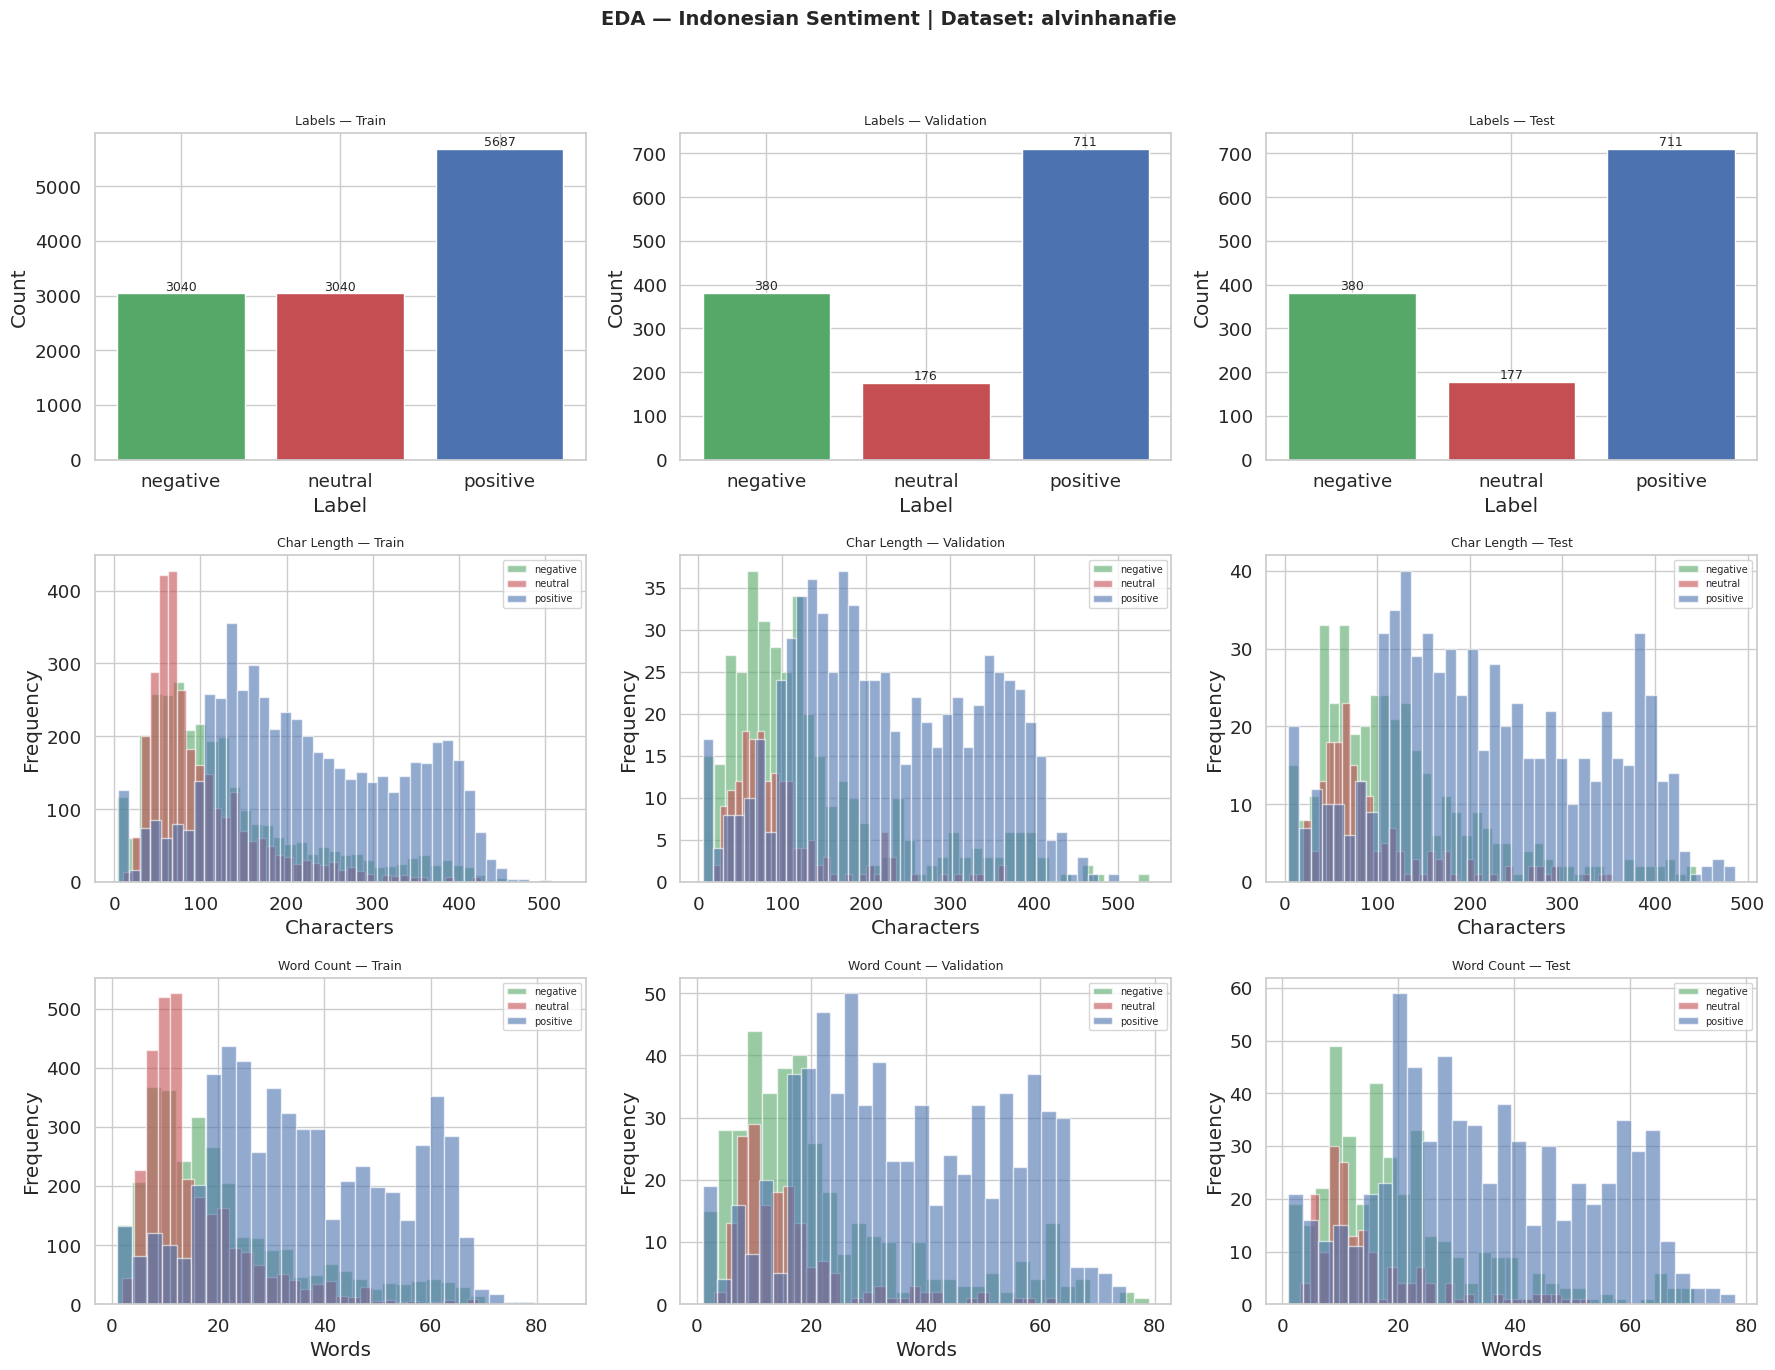

Saved: eda_overview.png


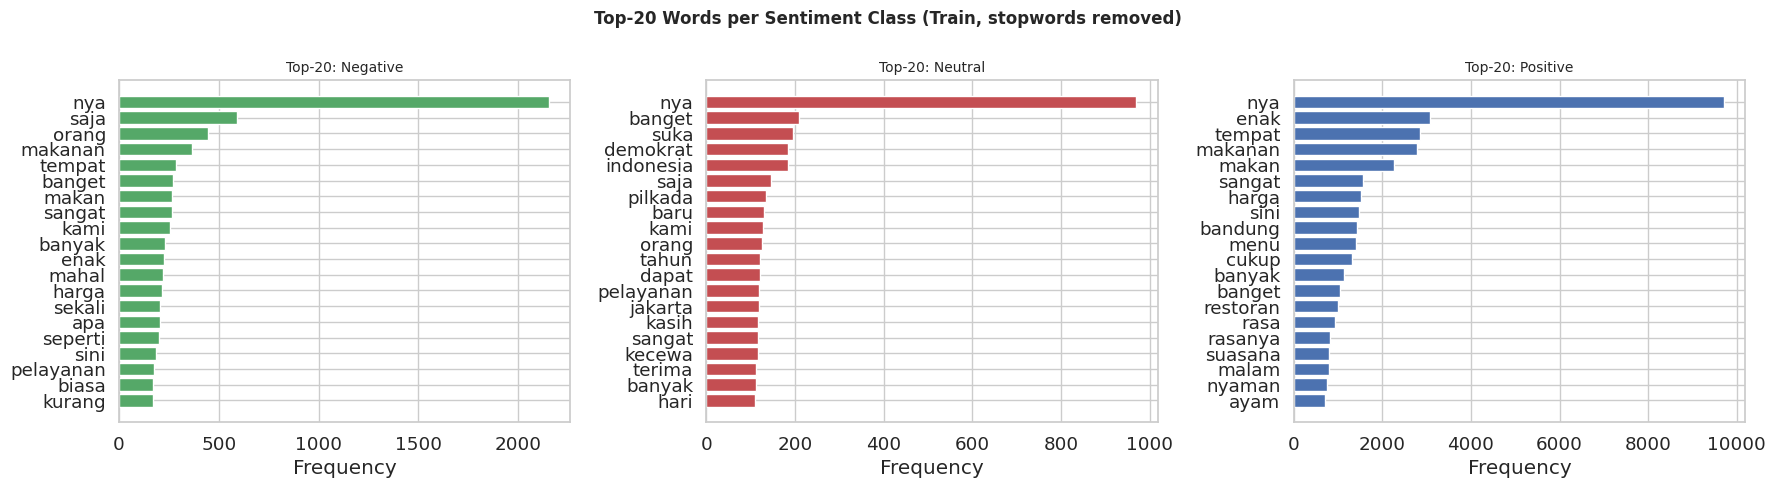

Saved: eda_top_words.png


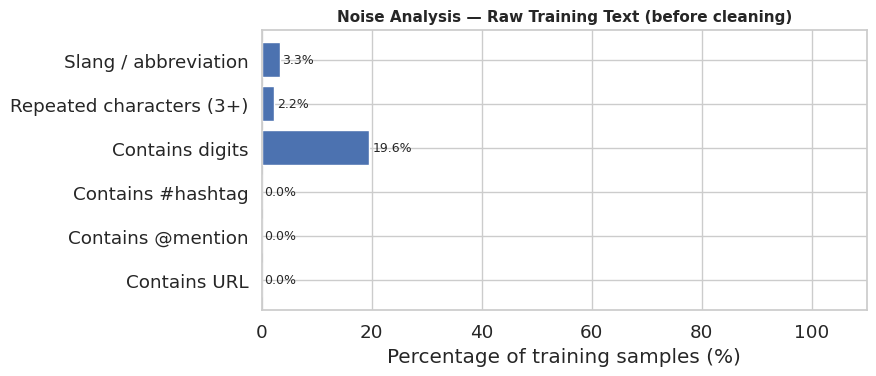

Saved: eda_noise_analysis.png

SUMMARY STATISTICS (post-cleaning)

[TRAIN]
  Total samples  : 11767
  Avg char length: 168.3  (max: 522)
  Avg word count : 27.0  (max: 85)
  positive    :  5687  (48.3%)
  neutral     :  3040  (25.8%)
  negative    :  3040  (25.8%)

[VALIDATION]
  Total samples  : 1267
  Avg char length: 180.0  (max: 537)
  Avg word count : 29.1  (max: 79)
  positive    :   711  (56.1%)
  negative    :   380  (30.0%)
  neutral     :   176  (13.9%)

[TEST]
  Total samples  : 1268
  Avg char length: 174.3  (max: 486)
  Avg word count : 28.0  (max: 78)
  positive    :   711  (56.1%)
  negative    :   380  (30.0%)
  neutral     :   177  (14.0%)

Class imbalance ratio (train): 1.87x  ✓  balanced

Tip: re-run  run_eda(raw_datasets, teacher_tok=teacher_tokenizer)  after Cell 12 to include token-length plots.


In [10]:
# Cell 10: EDA — Exploratory Data Analysis
# ─────────────────────────────────────────────────────────────────────────────
from collections import Counter

STOPWORDS_ID = {
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "dengan", "untuk",
    "pada", "adalah", "atau", "juga", "saya", "tidak", "kamu", "ada",
    "sudah", "akan", "bisa", "lagi", "dalam", "karena", "lebih", "tapi",
    "jadi", "kalau", "kita", "mereka", "satu", "dua", "tiga",
    "belum", "sama", "pun", "mau", "sih", "aja", "deh", "lah", "dong",
    "ya", "iya", "oh", "ah", "hm", "nih", "kan", "yah",
}


def run_eda(datasets: DatasetDict, teacher_tok=None):
    splits     = ["train", "validation", "test"]
    all_lbls   = sorted(set(datasets["train"]["label"]))
    palette    = ["#55A868", "#C44E52", "#4C72B0", "#DD8452", "#8172B2"]
    lbl_colors = {l: palette[i % len(palette)] for i, l in enumerate(all_lbls)}

    all_dfs = {}
    for split in splits:
        df              = pd.DataFrame(datasets[split])
        df["text_len"]  = df["text"].str.len()
        df["word_count"]= df["text"].str.split().str.len()
        if teacher_tok is not None:
            df["token_count"] = df["text"].apply(
                lambda t: len(teacher_tok.encode(t, add_special_tokens=True))
            )
        all_dfs[split] = df

    # Fig 1: Label distribution + char length + word count
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    fig.suptitle(f"EDA — Indonesian Sentiment | Dataset: alvinhanafie",
                 fontsize=14, fontweight="bold")

    for idx, split in enumerate(splits):
        df     = all_dfs[split]
        counts = df["label"].value_counts().sort_index()
        bar_c  = [lbl_colors.get(l, "#999") for l in counts.index]
        bars   = axes[0][idx].bar(counts.index, counts.values, color=bar_c, edgecolor="white")
        for bar, val in zip(bars, counts.values):
            axes[0][idx].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                              str(val), ha="center", va="bottom", fontsize=9)
        axes[0][idx].set_title(f"Labels — {split.capitalize()}", fontsize=9)
        axes[0][idx].set_xlabel("Label")
        axes[0][idx].set_ylabel("Count")

    for idx, split in enumerate(splits):
        df = all_dfs[split]
        for lbl, color in lbl_colors.items():
            sub = df[df["label"] == lbl]["text_len"]
            if len(sub):
                axes[1][idx].hist(sub, bins=40, alpha=0.6, color=color, label=lbl)
        axes[1][idx].set_title(f"Char Length — {split.capitalize()}", fontsize=9)
        axes[1][idx].set_xlabel("Characters")
        axes[1][idx].set_ylabel("Frequency")
        axes[1][idx].legend(fontsize=7)

    for idx, split in enumerate(splits):
        df = all_dfs[split]
        for lbl, color in lbl_colors.items():
            sub = df[df["label"] == lbl]["word_count"]
            if len(sub):
                axes[2][idx].hist(sub, bins=30, alpha=0.6, color=color, label=lbl)
        axes[2][idx].set_title(f"Word Count — {split.capitalize()}", fontsize=9)
        axes[2][idx].set_xlabel("Words")
        axes[2][idx].set_ylabel("Frequency")
        axes[2][idx].legend(fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(OUTPUT_DIR, "eda_overview.png"), dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: eda_overview.png")

    # Fig 2: Token-length distribution
    if teacher_tok is not None:
        fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
        fig2.suptitle(f"Token Length After IndoBERT Tokenisation (MAX_LENGTH = {MAX_LENGTH})",
                      fontsize=12, fontweight="bold")
        for idx, split in enumerate(splits):
            df = all_dfs[split]
            for lbl, color in lbl_colors.items():
                sub = df[df["label"] == lbl]["token_count"]
                if len(sub):
                    axes2[idx].hist(sub, bins=30, alpha=0.6, color=color, label=lbl)
            axes2[idx].axvline(MAX_LENGTH, color="red", linestyle="--", linewidth=1.2,
                               label="truncation boundary")
            pct = (df["token_count"] > MAX_LENGTH).mean() * 100
            axes2[idx].set_title(f"{split.capitalize()} — truncated: {pct:.1f}%", fontsize=9)
            axes2[idx].set_xlabel("Tokens")
            axes2[idx].set_ylabel("Frequency")
            axes2[idx].legend(fontsize=7)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "eda_token_length.png"), dpi=120)
        plt.show()
        print("Saved: eda_token_length.png")

    # Fig 3: Top-20 words per sentiment class
    fig3, axes3 = plt.subplots(1, len(all_lbls), figsize=(6 * len(all_lbls), 5))
    if len(all_lbls) == 1:
        axes3 = [axes3]
    fig3.suptitle("Top-20 Words per Sentiment Class (Train, stopwords removed)",
                  fontsize=12, fontweight="bold")
    train_df = all_dfs["train"]
    for idx, lbl in enumerate(all_lbls):
        color = lbl_colors.get(lbl, "#4C72B0")
        words = [
            w for s in train_df[train_df["label"] == lbl]["text"]
            for w in s.split()
            if w not in STOPWORDS_ID and len(w) > 2
        ]
        top20 = Counter(words).most_common(20)
        if top20:
            ws, fs = zip(*top20)
            axes3[idx].barh(list(ws)[::-1], list(fs)[::-1], color=color, edgecolor="white")
        axes3[idx].set_title(f"Top-20: {lbl.capitalize()}", fontsize=10)
        axes3[idx].set_xlabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "eda_top_words.png"), dpi=120)
    plt.show()
    print("Saved: eda_top_words.png")

    # Fig 4: Noise analysis
    if "raw_text" in all_dfs["train"].columns:
        raw_col  = all_dfs["train"]["raw_text"]
        slang_pat = r"\b(" + "|".join(
            re.escape(k) for k in list(SLANG_DICT.keys())[:40]
        ) + r")\b"
        noise_stats = {
            "Contains URL"             : raw_col.str.contains(r"https?://", regex=True, na=False).mean(),
            "Contains @mention"        : raw_col.str.contains(r"@\w+",    regex=True, na=False).mean(),
            "Contains #hashtag"        : raw_col.str.contains(r"#\w+",    regex=True, na=False).mean(),
            "Contains digits"          : raw_col.str.contains(r"\d",      regex=True, na=False).mean(),
            "Repeated characters (3+)" : raw_col.str.contains(r"(.)\1{2,}",regex=True, na=False).mean(),
            "Slang / abbreviation"     : raw_col.str.lower().str.contains(slang_pat, regex=True, na=False).mean(),
        }
        fig4, ax4 = plt.subplots(figsize=(9, 4))
        labels_n = list(noise_stats.keys())
        values_n = [v * 100 for v in noise_stats.values()]
        bars_n   = ax4.barh(labels_n, values_n, color="#4C72B0", edgecolor="white")
        for bar, val in zip(bars_n, values_n):
            ax4.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=9)
        ax4.set_xlim(0, 110)
        ax4.set_xlabel("Percentage of training samples (%)")
        ax4.set_title("Noise Analysis — Raw Training Text (before cleaning)",
                      fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "eda_noise_analysis.png"), dpi=120)
        plt.show()
        print("Saved: eda_noise_analysis.png")

    # Summary statistics
    print("\n" + "=" * 62)
    print("SUMMARY STATISTICS (post-cleaning)")
    print("=" * 62)
    for split in splits:
        df = all_dfs[split]
        print(f"\n[{split.upper()}]")
        print(f"  Total samples  : {len(df)}")
        print(f"  Avg char length: {df['text_len'].mean():.1f}  (max: {df['text_len'].max()})")
        print(f"  Avg word count : {df['word_count'].mean():.1f}  (max: {df['word_count'].max()})")
        if teacher_tok is not None and "token_count" in df.columns:
            pct = (df["token_count"] > MAX_LENGTH).mean() * 100
            print(f"  Avg token count: {df['token_count'].mean():.1f}  (>{MAX_LENGTH}: {pct:.1f}%)")
        for lbl, cnt in df["label"].value_counts().items():
            print(f"  {lbl:<12}: {cnt:>5}  ({cnt / len(df) * 100:.1f}%)")

    dist  = all_dfs["train"]["label"].value_counts()
    ratio = dist.max() / dist.min()
    print(f"\nClass imbalance ratio (train): {ratio:.2f}x  "
          f"{'⚠  imbalanced' if ratio > 2 else '✓  balanced'}")


run_eda(raw_datasets, teacher_tok=None)
print("\nTip: re-run  run_eda(raw_datasets, teacher_tok=teacher_tokenizer)  after Cell 12 "
      "to include token-length plots.")


In [11]:
# Cell 11: Label encoding — map string labels to integer class indices
# ─────────────────────────────────────────────────────────────────────────────
# Sorted alphabetically: negative→0, neutral→1, positive→2 (for 3 classes)
# For 2 classes (positive/negative): negative→0, positive→1
all_labels = sorted({lbl for split in raw_datasets.values() for lbl in split["label"]})
label2id   = {l: i for i, l in enumerate(all_labels)}
id2label   = {i: l for i, l in enumerate(all_labels)}
num_labels = len(all_labels)

print(f"Labels ({num_labels}) : {all_labels}")
print(f"label2id             : {label2id}")


def encode_labels(example: dict) -> dict:
    example["label"] = label2id[example["label"]]
    return example


raw_datasets = raw_datasets.map(encode_labels)
print("✓ Label encoding done.")


Labels (3) : ['negative', 'neutral', 'positive']
label2id             : {'negative': 0, 'neutral': 1, 'positive': 2}


Map:   0%|          | 0/11767 [00:00<?, ? examples/s]

Map:   0%|          | 0/1267 [00:00<?, ? examples/s]

Map:   0%|          | 0/1268 [00:00<?, ? examples/s]

✓ Label encoding done.


In [12]:
# Cell 12: Load tokenizers
# ─────────────────────────────────────────────────────────────────────────────
teacher_tokenizer = AutoTokenizer.from_pretrained(TEACHER_NAME)
student_tokenizer = AutoTokenizer.from_pretrained(STUDENT_NAME)

print(f"Teacher tokenizer : {TEACHER_NAME}  (vocab: {teacher_tokenizer.vocab_size:,})")
print(f"Student tokenizer : {STUDENT_NAME}  (vocab: {student_tokenizer.vocab_size:,})")

_test = "saya suka makan nasi goreng"
t_ids = teacher_tokenizer(_test)["input_ids"]
s_ids = student_tokenizer(_test)["input_ids"]
print(f"\nTest sentence : '{_test}'")
print(f"  Teacher IDs : {t_ids}")
print(f"  Student IDs : {s_ids}")

assert teacher_tokenizer.vocab_size != student_tokenizer.vocab_size, \
    "Vocab sizes are identical — did you accidentally load the same model twice?"
assert t_ids != s_ids, \
    "Token IDs are identical — tokenizers are not genuinely different models."
print("\n✓ Tokenizers verified — genuinely different vocabularies.")


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Teacher tokenizer : indobenchmark/indobert-base-p1  (vocab: 30,521)
Student tokenizer : distilbert-base-multilingual-cased  (vocab: 119,547)

Test sentence : 'saya suka makan nasi goreng'
  Teacher IDs : [2, 209, 1506, 521, 3210, 5259, 3]
  Student IDs : [101, 64981, 10198, 10371, 76306, 12947, 10116, 11783, 67398, 102]

✓ Tokenizers verified — genuinely different vocabularies.


In [13]:
# Cell 13: Tokenise datasets for standalone teacher/student training
# ─────────────────────────────────────────────────────────────────────────────
def tokenize_fn(examples: dict, tokenizer) -> dict:
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )


# Drop raw_text column if it exists
def _get_remove_cols(ds):
    return [c for c in ["text", "raw_text"] if c in ds.column_names]


teacher_datasets = raw_datasets.map(
    lambda x: tokenize_fn(x, teacher_tokenizer),
    batched=True,
    remove_columns=_get_remove_cols(raw_datasets["train"]),
    desc="Tokenising (teacher)",
)
student_datasets = raw_datasets.map(
    lambda x: tokenize_fn(x, student_tokenizer),
    batched=True,
    remove_columns=_get_remove_cols(raw_datasets["train"]),
    desc="Tokenising (student)",
)

print("Teacher dataset columns:", teacher_datasets["train"].column_names)
print("Student dataset columns:", student_datasets["train"].column_names)


Tokenising (teacher):   0%|          | 0/11767 [00:00<?, ? examples/s]

Tokenising (teacher):   0%|          | 0/1267 [00:00<?, ? examples/s]

Tokenising (teacher):   0%|          | 0/1268 [00:00<?, ? examples/s]

Tokenising (student):   0%|          | 0/11767 [00:00<?, ? examples/s]

Tokenising (student):   0%|          | 0/1267 [00:00<?, ? examples/s]

Tokenising (student):   0%|          | 0/1268 [00:00<?, ? examples/s]

Teacher dataset columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Student dataset columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [14]:
# Cell 14: Dual-tokenise for Knowledge Distillation
# ─────────────────────────────────────────────────────────────────────────────
def preprocess_function(examples: dict) -> dict:
    student_enc = student_tokenizer(
        examples["text"], max_length=MAX_LENGTH, truncation=True, padding=False,
    )
    teacher_enc = teacher_tokenizer(
        examples["text"], max_length=MAX_LENGTH, truncation=True, padding=False,
    )
    teacher_tti = teacher_enc.get(
        "token_type_ids",
        [[0] * len(ids) for ids in teacher_enc["input_ids"]],
    )
    return {
        "input_ids":              student_enc["input_ids"],
        "attention_mask":         student_enc["attention_mask"],
        "teacher_input_ids":      teacher_enc["input_ids"],
        "teacher_attention_mask": teacher_enc["attention_mask"],
        "teacher_token_type_ids": teacher_tti,
        "label":                  examples["label"],
    }


KEEP_COLS = {
    "input_ids", "attention_mask",
    "teacher_input_ids", "teacher_attention_mask", "teacher_token_type_ids",
    "label",
}

kd_datasets = raw_datasets.map(
    preprocess_function,
    batched=True,
    load_from_cache_file=False,
    remove_columns=[c for c in raw_datasets["train"].column_names if c not in KEEP_COLS],
    desc="Dual-tokenising for KD",
)
kd_datasets.set_format("torch")

kd_train_dataset = kd_datasets["train"]
kd_valid_dataset = kd_datasets["validation"]
kd_test_dataset  = kd_datasets["test"]

print("KD dataset columns :", kd_train_dataset.column_names)
print(f"Train  : {len(kd_train_dataset)}")
print(f"Valid  : {len(kd_valid_dataset)}")
print(f"Test   : {len(kd_test_dataset)}")


Dual-tokenising for KD:   0%|          | 0/11767 [00:00<?, ? examples/s]

Dual-tokenising for KD:   0%|          | 0/1267 [00:00<?, ? examples/s]

Dual-tokenising for KD:   0%|          | 0/1268 [00:00<?, ? examples/s]

KD dataset columns : ['label', 'input_ids', 'attention_mask', 'teacher_input_ids', 'teacher_attention_mask', 'teacher_token_type_ids']
Train  : 11767
Valid  : 1267
Test   : 1268


In [15]:
# Cell 15: KDDataCollator — batching for dual-tokenised KD datasets
# ─────────────────────────────────────────────────────────────────────────────
@dataclass
class KDDataCollator:
    student_tokenizer: Any
    teacher_tokenizer: Any

    def __call__(self, features: list) -> dict:
        def to_list(v):
            return v.tolist() if isinstance(v, torch.Tensor) else list(v)

        student_feats = [
            {"input_ids":      to_list(f["input_ids"]),
             "attention_mask": to_list(f["attention_mask"])}
            for f in features
        ]
        teacher_feats = [
            {"input_ids":      to_list(f["teacher_input_ids"]),
             "attention_mask": to_list(f["teacher_attention_mask"]),
             "token_type_ids": to_list(f["teacher_token_type_ids"])}
            for f in features
        ]
        labels = torch.tensor([int(f["label"]) for f in features], dtype=torch.long)

        s_batch = self.student_tokenizer.pad(student_feats, padding=True, return_tensors="pt")
        t_batch = self.teacher_tokenizer.pad(teacher_feats, padding=True, return_tensors="pt")

        return {
            "input_ids":              s_batch["input_ids"],
            "attention_mask":         s_batch["attention_mask"],
            "teacher_input_ids":      t_batch["input_ids"],
            "teacher_attention_mask": t_batch["attention_mask"],
            "teacher_token_type_ids": t_batch["token_type_ids"],
            "labels":                 labels,
        }


kd_data_collator = KDDataCollator(
    student_tokenizer=student_tokenizer,
    teacher_tokenizer=teacher_tokenizer,
)
print("✓ KDDataCollator ready.")


✓ KDDataCollator ready.


In [16]:
# Cell 16: Optional class weights
# ─────────────────────────────────────────────────────────────────────────────
def get_class_weights(dataset) -> torch.Tensor:
    y = np.array(dataset["label"])
    w = compute_class_weight("balanced", classes=np.unique(y), y=y)
    return torch.tensor(w, dtype=torch.float)


CLASS_WEIGHTS = get_class_weights(teacher_datasets["train"]) if USE_CLASS_WEIGHT else None

if CLASS_WEIGHTS is not None:
    print(f"Class weights: {dict(zip(all_labels, CLASS_WEIGHTS.numpy().round(4)))}")
else:
    print("Class weights: disabled  (USE_CLASS_WEIGHT=False)")
    print("Tip: Set USE_CLASS_WEIGHT=True in Cell 4 if your dataset is imbalanced.")


Class weights: {'negative': np.float32(1.2902), 'neutral': np.float32(1.2902), 'positive': np.float32(0.6897)}


In [17]:
# Cell 17: Evaluation metrics
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(eval_pred: EvalPrediction) -> dict:
    logits, labels = eval_pred
    preds    = np.argmax(logits, axis=-1)
    macro_f1 = sk_f1(labels, preds, average="macro", zero_division=0)
    report   = classification_report(
        labels, preds, target_names=all_labels, zero_division=0,
    )
    return {"f1": macro_f1, "report": report}


In [18]:
# Cell 18: MetricsLoggerCallback — per-epoch history for post-training plots
# ─────────────────────────────────────────────────────────────────────────────
class MetricsLoggerCallback(TrainerCallback):

    def __init__(self, model_name: str):
        self.model_name       = model_name
        self._last_train_loss = None
        self.history          = {"epoch": [], "train_loss": [], "eval_loss": [], "eval_f1": []}

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self._last_train_loss = logs["loss"]

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return
        epoch = int(math.ceil(state.epoch))
        tl    = self._last_train_loss
        el    = metrics.get("eval_loss")
        f1    = metrics.get("eval_f1")
        self.history["epoch"].append(epoch)
        self.history["train_loss"].append(tl)
        self.history["eval_loss"].append(el)
        self.history["eval_f1"].append(f1)
        tl_str = f"{tl:.4f}" if tl is not None else "N/A"
        el_str = f"{el:.4f}" if el is not None else "N/A"
        f1_str = f"{f1:.4f}" if f1 is not None else "N/A"
        print(
            f"  [{self.model_name}] Epoch {epoch:>2} | "
            f"train_loss: {tl_str:>7} | "
            f"eval_loss: {el_str:>7} | "
            f"eval_F1: {f1_str:>7}"
        )


teacher_cb = MetricsLoggerCallback("Teacher")
sd_cb      = MetricsLoggerCallback("Self-Distilled-Teacher")
no_kd_cb   = MetricsLoggerCallback("Student-no-KD")
kd_cb      = MetricsLoggerCallback("Student-with-KD")
print("✓ Callbacks ready.")


✓ Callbacks ready.


In [19]:
# Cell 19: TrainingArguments factory
# ─────────────────────────────────────────────────────────────────────────────
def make_training_args(output_dir: str, lr: float) -> TrainingArguments:
    return TrainingArguments(
        output_dir                  = output_dir,
        num_train_epochs            = NUM_EPOCHS,
        per_device_train_batch_size = TRAIN_BATCH_SIZE,
        per_device_eval_batch_size  = EVAL_BATCH_SIZE,
        learning_rate               = lr,
        weight_decay                = WEIGHT_DECAY,
        warmup_ratio                = WARMUP_RATIO,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "eval_f1",
        greater_is_better           = True,
        save_total_limit            = 2,
        logging_steps               = 50,
        report_to                   = "none",
        fp16                        = (DEVICE_TYPE == "gpu"),
        remove_unused_columns       = False,
    )


print("✓ make_training_args defined.")


✓ make_training_args defined.


In [20]:
# Cell 20: _filter_model_inputs helper
# ─────────────────────────────────────────────────────────────────────────────
def _filter_model_inputs(model: nn.Module, inputs: dict) -> dict:
    always_exclude = {
        "teacher_input_ids", "teacher_attention_mask",
        "teacher_token_type_ids", "labels",
    }
    accepted = set(inspect.signature(model.forward).parameters.keys())
    return {k: v for k, v in inputs.items() if k not in always_exclude and k in accepted}


print("✓ _filter_model_inputs defined.")


✓ _filter_model_inputs defined.


In [21]:
# Cell 21: SelfDistillTrainer
# ─────────────────────────────────────────────────────────────────────────────
class SelfDistillTrainer(Trainer):

    def __init__(self, frozen_teacher, *args,
                 temperature=SD_TEMPERATURE, alpha=SD_ALPHA, **kwargs):
        super().__init__(*args, **kwargs)
        self.frozen_teacher = frozen_teacher.eval()
        self.temperature    = temperature
        self.alpha          = alpha

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        # Unwrap DataParallel if present so signature inspection works correctly
        raw_model   = model.module if hasattr(model, "module") else model
        raw_teacher = (
            self.frozen_teacher.module
            if hasattr(self.frozen_teacher, "module")
            else self.frozen_teacher
        )

        student_inputs = {
            k: v for k, v in inputs.items()
            if k in set(inspect.signature(raw_model.forward).parameters)
            and k not in {"labels"}
        }
        student_out = model(**student_inputs, output_hidden_states=False)

        teacher_inputs = {
            k: v for k, v in inputs.items()
            if k in set(inspect.signature(raw_teacher.forward).parameters)
            and k not in {"labels"}
        }
        with torch.no_grad():
            teacher_out = self.frozen_teacher(**teacher_inputs, output_hidden_states=False)

        T       = self.temperature
        loss_ce = F.cross_entropy(student_out.logits, labels)
        loss_kl = F.kl_div(
            F.log_softmax(student_out.logits / T, dim=-1),
            F.softmax(teacher_out.logits  / T, dim=-1),
            reduction="batchmean",
        ) * (T ** 2)
        loss = (1 - self.alpha) * loss_ce + self.alpha * loss_kl
        return (loss, student_out) if return_outputs else loss


In [22]:
# Cell 22: ALMKDTrainer — full knowledge distillation with ALM-KD loss
# ─────────────────────────────────────────────────────────────────────────────
class ALMKDTrainer(Trainer):

    def __init__(
        self, teacher_model, *args,
        alpha=ALM_ALPHA, alpha_end=ALM_ALPHA_END,
        beta=ALM_BETA, delta=ALM_DELTA, eta=ALM_ETA,
        temperature=ALM_TEMPERATURE, gamma=ALM_GAMMA,
        class_weights=None, use_dynamic_alpha=USE_DYNAMIC_ALPHA,
        label_smoothing=LABEL_SMOOTHING, **kwargs,
    ):
        super().__init__(*args, **kwargs)
        self.teacher           = teacher_model.eval()
        self.alpha_start       = alpha
        self.alpha_end         = alpha_end
        self.alpha             = alpha
        self.beta              = beta
        self.delta             = delta
        self.eta               = eta
        self.temperature       = temperature
        self.gamma             = gamma
        self.class_weights     = class_weights
        self.use_dynamic_alpha = use_dynamic_alpha
        self.label_smoothing   = label_smoothing
        self._current_epoch    = 0

        s_dim = self.model.config.hidden_size
        t_dim = self.teacher.config.hidden_size
        self.model.cls_projector = nn.Linear(s_dim, t_dim, bias=True)
        self.model.cls_projector.to(self.model.device)
        nn.init.xavier_uniform_(self.model.cls_projector.weight)
        nn.init.zeros_(self.model.cls_projector.bias)

        self._use_attn_transfer = (eta > 0.0)
        self._student_keys = (
            set(inspect.signature(self.model.forward).parameters)
            - {"teacher_input_ids", "teacher_attention_mask", "teacher_token_type_ids", "labels"}
        )
        self._projector_ckpt_path = None

    def create_optimizer(self):
        if self.optimizer is None:
            no_decay = ["bias", "LayerNorm.weight"]
            decay_p, no_decay_p = [], []
            for name, param in self.model.named_parameters():
                (no_decay_p if any(nd in name for nd in no_decay) else decay_p).append(param)
            optimizer_cls, optimizer_kwargs = Trainer.get_optimizer_cls_and_kwargs(self.args)
            self.optimizer = optimizer_cls(
                [{"params": decay_p,    "weight_decay": self.args.weight_decay},
                 {"params": no_decay_p, "weight_decay": 0.0}],
                **optimizer_kwargs,
            )
        return self.optimizer

    def _update_alpha(self, epoch: int):
        # Pakai self._total_epochs (diset saat train()) bukan NUM_EPOCHS global
        # supaya dynamic alpha bekerja benar baik di full training maupun CV fold
        total = getattr(self, "_total_epochs", NUM_EPOCHS)
        if not self.use_dynamic_alpha or total <= 1:
            return
        progress   = (epoch - 1) / max(total - 1, 1)
        self.alpha = self.alpha_start + progress * (self.alpha_end - self.alpha_start)

    def train(self, *args, **kwargs):
        # Tangkap jumlah epoch aktual dari TrainingArguments sebelum training mulai
        self._total_epochs = int(self.args.num_train_epochs)
        return super().train(*args, **kwargs)

    def _save_checkpoint(self, model, trial, **kwargs):
        super()._save_checkpoint(model, trial, **kwargs)
        proj_path = os.path.join(self._get_output_dir(trial), "cls_projector.pt")
        torch.save(self.model.cls_projector.state_dict(), proj_path)
        self._projector_ckpt_path = proj_path

    def _load_best_model(self):
        super()._load_best_model()
        if self._projector_ckpt_path and os.path.exists(self._projector_ckpt_path):
            self.model.cls_projector.load_state_dict(
                torch.load(self._projector_ckpt_path, map_location="cpu")
            )

    def _compute_pkd_loss(self, s_hidden, t_hidden, raw_model) -> torch.Tensor:
        """
        Patient KD loss: cosine similarity antara CLS token tiap layer student
        dan layer teacher yang bersesuaian.
        Pakai cls_projector untuk project student dim → teacher dim,
        konsisten dengan loss_cls. Ini penting kalau s_dim != t_dim.
        """
        losses = []
        for i in range(1, len(s_hidden)):
            t_idx  = min(i * 2, len(t_hidden) - 1)
            s_cls  = s_hidden[i][:, 0, :]
            t_cls  = t_hidden[t_idx][:, 0, :].detach()
            # Project student CLS → teacher dim space
            s_proj = raw_model.cls_projector(s_cls)
            target = torch.ones(s_proj.size(0), device=s_proj.device)
            losses.append(F.cosine_embedding_loss(s_proj, t_cls, target))
        return torch.stack(losses).mean()

    def _compute_attention_loss(self, s_attns, t_attns) -> torch.Tensor:
        losses = []
        for i, s_attn in enumerate(s_attns):
            t_idx  = min(i * 2 + 1, len(t_attns) - 1)
            t_attn = t_attns[t_idx].detach()
            s_map  = s_attn.mean(dim=1)
            t_map  = t_attn.mean(dim=1)
            if s_map.shape != t_map.shape:
                seq_t = t_map.size(-1)
                s_map = F.interpolate(
                    s_map.unsqueeze(1), size=(seq_t, seq_t),
                    mode="bilinear", align_corners=False,
                ).squeeze(1)
            losses.append(F.mse_loss(s_map, t_map))
        return torch.stack(losses).mean()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels                 = inputs["labels"]
        teacher_input_ids      = inputs.get("teacher_input_ids")
        teacher_attention_mask = inputs.get("teacher_attention_mask")
        teacher_token_type_ids = inputs.get("teacher_token_type_ids")
        is_training            = model.training

        if is_training and self.state is not None:
            epoch = int(math.ceil(self.state.epoch or 1))
            if epoch != self._current_epoch:
                self._current_epoch = epoch
                self._update_alpha(epoch)
                print(f"  [ALMKDTrainer] Epoch {epoch} | α = {self.alpha:.4f}")

        student_inputs = {k: v for k, v in inputs.items() if k in self._student_keys}
        student_out = model(
            **student_inputs,
            output_hidden_states = is_training,
            output_attentions    = is_training and self._use_attn_transfer,
        )
        dev = student_out.logits.device

        loss_ce = F.cross_entropy(
            student_out.logits, labels.to(dev),
            weight=self.class_weights.to(dev) if self.class_weights is not None else None,
            label_smoothing=self.label_smoothing,
        )

        if not is_training:
            return (loss_ce, student_out) if return_outputs else loss_ce

        with torch.no_grad():
            t_kwargs = dict(
                input_ids            = teacher_input_ids.to(dev),
                attention_mask       = teacher_attention_mask.to(dev),
                output_hidden_states = True,
                output_attentions    = self._use_attn_transfer,
            )
            if teacher_token_type_ids is not None:
                t_kwargs["token_type_ids"] = teacher_token_type_ids.to(dev)
            teacher_out = self.teacher(**t_kwargs)

        T = self.temperature
        with torch.no_grad():
            t_probs      = F.softmax(teacher_out.logits / T, dim=-1)
            debias_mask  = (t_probs > self.gamma).float()
            t_debiased   = t_probs * debias_mask
            t_debiased   = t_debiased / t_debiased.sum(dim=-1, keepdim=True).clamp(min=1e-8)

        loss_kl = F.kl_div(
            F.log_softmax(student_out.logits / T, dim=-1),
            t_debiased, reduction="batchmean",
        ) * (T ** 2)

        s_cls       = student_out.hidden_states[-1][:, 0, :]
        t_mid       = teacher_out.hidden_states[len(teacher_out.hidden_states) // 2][:, 0, :].detach()
        raw_model   = model.module if hasattr(model, "module") else model
        s_cls_proj  = raw_model.cls_projector(s_cls)
        loss_cls    = F.cosine_embedding_loss(
            s_cls_proj, t_mid, torch.ones(s_cls_proj.size(0), device=dev)
        )

        loss_pkd = self._compute_pkd_loss(student_out.hidden_states, teacher_out.hidden_states, raw_model)

        loss_attn = torch.tensor(0.0, device=dev)
        if (self._use_attn_transfer
                and student_out.attentions is not None
                and teacher_out.attentions is not None):
            loss_attn = self._compute_attention_loss(
                student_out.attentions, teacher_out.attentions
            )

        # ce_weight dihitung dinamis dari alpha yang bisa berubah tiap epoch
        # Normalisasi: total weights selalu sum ke 1.0
        fixed_weight = self.beta + self.delta + self.eta   # komponen yang tidak berubah
        ce_weight    = max(1.0 - self.alpha - fixed_weight, 0.05)

        # Normalisasi eksplisit agar total = 1.0 (penting saat dynamic alpha aktif)
        total_w = ce_weight + self.alpha + fixed_weight
        ce_w    = ce_weight / total_w
        kl_w    = self.alpha / total_w
        cls_w   = self.beta  / total_w
        pkd_w   = self.delta / total_w
        attn_w  = self.eta   / total_w

        loss_kl   = loss_kl.clamp(min=0.0)   # guard fp16 rounding
        loss      = (
            ce_w   * loss_ce
            + kl_w   * loss_kl
            + cls_w  * loss_cls
            + pkd_w  * loss_pkd
            + attn_w * loss_attn
        )
        return (loss, student_out) if return_outputs else loss


print("✓ ALMKDTrainer defined.")
print(f"  Loss components: CE + KL(α={ALM_ALPHA}→{ALM_ALPHA_END}) + CLS(β={ALM_BETA})"
      f" + PKD(δ={ALM_DELTA}) + Attn(η={ALM_ETA})")


✓ ALMKDTrainer defined.
  Loss components: CE + KL(α=0.5→0.2) + CLS(β=0.2) + PKD(δ=0.1) + Attn(η=0.05)


In [23]:
# Cell 23: Sanity check — KD dataset columns dan collator output shape
# ─────────────────────────────────────────────────────────────────────────────
required_cols = [
    "input_ids", "attention_mask",
    "teacher_input_ids", "teacher_attention_mask", "teacher_token_type_ids",
    "label",
]
for col in required_cols:
    assert col in kd_train_dataset.column_names, f"Missing column: {col}"
print("✓ All required columns present:", kd_train_dataset.column_names)

sample = kd_train_dataset[0]
print(f"\nSample — student tokens : {len(sample['input_ids'])}")
print(f"Sample — teacher tokens : {len(sample['teacher_input_ids'])}")
print(f"Sample — label          : {sample['label']} → {id2label[int(sample['label'])]}")

try:
    batch = kd_data_collator([kd_train_dataset[0], kd_train_dataset[1]])
    print("\n✓ Collator smoke-test passed")
    print(f"  student input_ids shape : {batch['input_ids'].shape}")
    print(f"  teacher input_ids shape : {batch['teacher_input_ids'].shape}")
    print(f"  labels shape            : {batch['labels'].shape}")
except Exception as e:
    print(f"\n✗ Collator smoke-test FAILED: {e}")
    raise
finally:
    kd_datasets.set_format("torch")
    kd_train_dataset = kd_datasets["train"]
    kd_valid_dataset = kd_datasets["validation"]
    kd_test_dataset  = kd_datasets["test"]


✓ All required columns present: ['label', 'input_ids', 'attention_mask', 'teacher_input_ids', 'teacher_attention_mask', 'teacher_token_type_ids']

Sample — student tokens : 22
Sample — teacher tokens : 19
Sample — label          : 1 → neutral

✓ Collator smoke-test passed
  student input_ids shape : torch.Size([2, 22])
  teacher input_ids shape : torch.Size([2, 19])
  labels shape            : torch.Size([2])


In [24]:
# Cell 24: Train teacher model — indobenchmark/indobert-base-p1
# ─────────────────────────────────────────────────────────────────────────────
teacher_model = AutoModelForSequenceClassification.from_pretrained(
    TEACHER_NAME,
    num_labels=num_labels, id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True,
)

teacher_trainer = Trainer(
    model            = teacher_model,
    args             = make_training_args(os.path.join(OUTPUT_DIR, "ckpt-teacher"), TEACHER_LR),
    train_dataset    = teacher_datasets["train"],
    eval_dataset     = teacher_datasets["validation"],
    processing_class = teacher_tokenizer,
    data_collator    = DataCollatorWithPadding(teacher_tokenizer),
    compute_metrics  = compute_metrics,
    callbacks        = [teacher_cb, EarlyStoppingCallback(EARLY_STOPPING_PATIENCE)],
)

teacher_trainer.train()
teacher_results = teacher_trainer.evaluate(teacher_datasets["test"])

print(f"\nTeacher  —  Test F1   : {teacher_results['eval_f1']:.4f}")
print(f"Teacher  —  Test Loss : {teacher_results['eval_loss']:.4f}")
print("\nClassification Report (Teacher):")
print(teacher_results.get("eval_report", ""))


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,F1,Report
1,0.543655,0.507550,0.867381,precision recall f1-score support negative 0.90 0.86 0.88 380 neutral 0.79 0.77 0.78 176 positive 0.93 0.96 0.94 711 accuracy 0.90 1267 macro avg 0.87 0.86 0.87 1267 weighted avg 0.90 0.90 0.90 1267
2,0.308628,0.544473,0.878836,precision recall f1-score support negative 0.89 0.91 0.90 380 neutral 0.89 0.72 0.79 176 positive 0.93 0.96 0.95 711 accuracy 0.91 1267 macro avg 0.90 0.86 0.88 1267 weighted avg 0.91 0.91 0.91 1267
3,0.159732,0.743478,0.882545,precision recall f1-score support negative 0.88 0.89 0.89 380 neutral 0.85 0.78 0.82 176 positive 0.94 0.95 0.94 711 accuracy 0.91 1267 macro avg 0.89 0.88 0.88 1267 weighted avg 0.91 0.91 0.91 1267
4,0.037475,1.018683,0.882893,precision recall f1-score support negative 0.87 0.92 0.89 380 neutral 0.89 0.74 0.81 176 positive 0.94 0.95 0.95 711 accuracy 0.91 1267 macro avg 0.90 0.87 0.88 1267 weighted avg 0.91 0.91 0.91 1267
5,0.046154,1.041320,0.887691,precision recall f1-score support negative 0.87 0.93 0.90 380 neutral 0.90 0.74 0.82 176 positive 0.94 0.95 0.95 711 accuracy 0.92 1267 macro avg 0.91 0.87 0.89 1267 weighted avg 0.92 0.92 0.92 1267


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [Teacher] Epoch  5 | train_loss:  0.0462 | eval_loss:  1.0413 | eval_F1:  0.8877


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  [Teacher] Epoch  5 | train_loss:  0.0462 | eval_loss:  1.1271 | eval_F1:  0.8697

Teacher  —  Test F1   : 0.8697
Teacher  —  Test Loss : 1.1271

Classification Report (Teacher):
              precision    recall  f1-score   support

    negative       0.87      0.90      0.88       380
     neutral       0.81      0.75      0.78       177
    positive       0.95      0.95      0.95       711

    accuracy                           0.91      1268
   macro avg       0.88      0.87      0.87      1268
weighted avg       0.91      0.91      0.91      1268



In [25]:
# Cell CV-1: Stratified K-Fold Cross-Validation (sebelum full training)
# ─────────────────────────────────────────────────────────────────────────────
# Cross-validation dijalankan SEBELUM full training untuk:
#   1. Estimasi generalisasi model yang lebih robust (mean ± std F1 across folds)
#   2. Membuktikan KD gain tidak hanya artifact dari satu split tertentu
#   3. Mendeteksi overfitting lebih awal (gap train-val F1 tiap fold)
#
# CV pool  : df_train + df_val (test tetap held-out, tidak pernah disentuh)
# Fold eval: dilakukan di fold_val (stratified), bukan test set
# Early stopping: aktif di setiap fold (patience = CV_ES_PATIENCE)
# ─────────────────────────────────────────────────────────────────────────────
import gc
from sklearn.model_selection import StratifiedKFold

# ── CV Config (bisa diubah di sini) ──────────────────────────────────────────
N_FOLDS          = 5     # 3 kalau VRAM / waktu terbatas
CV_NUM_EPOCHS    = 3     # Epoch max per fold (early stopping bisa berhenti lebih cepat)
CV_ES_PATIENCE   = 2     # Early stopping patience khusus CV (lebih agresif dari full training)
CV_BATCH_SIZE    = 16
CV_GRAD_ACCUM    = 2     # effective batch = 32
CV_SEED          = RANDOM_SEED

print(f"{'='*66}")
print(f"  Stratified {N_FOLDS}-Fold Cross-Validation")
print(f"  Epochs per fold : {CV_NUM_EPOCHS}  |  ES patience : {CV_ES_PATIENCE}")
print(f"{'='*66}\n")

# ── Gabung train+val → CV pool (test tetap held-out) ─────────────────────────
df_cv_pool    = pd.concat([df_train, df_val], ignore_index=True)
cv_labels_arr = df_cv_pool["label"].map(label2id).values
print(f"CV pool : {len(df_cv_pool)} samples | "
      f"Test (held-out) : {len(df_test)} samples\n")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=CV_SEED)

cv_no_kd_folds = []   # list of {"fold", "f1_macro", "f1_weighted", "best_epoch"}
cv_kd_folds    = []

# ── Helper: buat TrainingArguments untuk CV ───────────────────────────────────
def make_cv_training_args(output_dir: str, lr: float) -> TrainingArguments:
    return TrainingArguments(
        output_dir                  = output_dir,
        num_train_epochs            = CV_NUM_EPOCHS,
        per_device_train_batch_size = CV_BATCH_SIZE,
        per_device_eval_batch_size  = EVAL_BATCH_SIZE,
        gradient_accumulation_steps = CV_GRAD_ACCUM,
        learning_rate               = lr,
        weight_decay                = WEIGHT_DECAY,
        warmup_ratio                = WARMUP_RATIO,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,    # butuh save untuk load_best
        metric_for_best_model       = "eval_f1",
        greater_is_better           = True,
        save_total_limit            = 1,       # hemat disk: hanya simpan 1 ckpt
        logging_steps               = 50,
        report_to                   = "none",
        fp16                        = (DEVICE_TYPE == "gpu"),
        gradient_checkpointing      = True,
        remove_unused_columns       = False,
        dataloader_pin_memory       = False,
    )

# ── Helper: manual eval (bypass Trainer DataParallel) ────────────────────────
def eval_fold_manual(model, dataset, collator, device) -> dict:
    from torch.utils.data import DataLoader
    raw = model.module if hasattr(model, "module") else model
    raw = raw.to(device).eval()
    loader = DataLoader(dataset, batch_size=32, collate_fn=collator)
    all_logits, all_labels_list = [], []
    with torch.no_grad():
        for batch in loader:
            lbls     = batch.pop("labels", None)
            accepted = set(inspect.signature(raw.forward).parameters)
            batch    = {k: v.to(device) for k, v in batch.items() if k in accepted}
            out      = raw(**batch)
            all_logits.append(out.logits.cpu())
            if lbls is not None:
                all_labels_list.append(lbls.cpu())
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels_list).numpy()
    preds  = np.argmax(logits, axis=-1)
    return {
        "f1_macro":    sk_f1(labels, preds, average="macro",    zero_division=0),
        "f1_weighted": sk_f1(labels, preds, average="weighted", zero_division=0),
    }

fold_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ─────────────────────────────────────────────────────────────────────────────
#  K-FOLD LOOP
# ─────────────────────────────────────────────────────────────────────────────
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df_cv_pool, cv_labels_arr)):
    print(f"\n{'─'*60}")
    print(f"  FOLD {fold_idx+1}/{N_FOLDS}   train={len(train_idx)}  val={len(val_idx)}")
    print(f"{'─'*60}")

    fold_train_df = df_cv_pool.iloc[train_idx].reset_index(drop=True)
    fold_val_df   = df_cv_pool.iloc[val_idx].reset_index(drop=True)

    y_fold = fold_train_df["label"].map(label2id).values
    fold_weights = (
        torch.tensor(
            compute_class_weight("balanced", classes=np.unique(y_fold), y=y_fold),
            dtype=torch.float,
        ) if USE_CLASS_WEIGHT else None
    )

    fold_raw = DatasetDict({
        "train":      Dataset.from_pandas(fold_train_df, preserve_index=False),
        "validation": Dataset.from_pandas(fold_val_df,   preserve_index=False),
    })
    fold_raw = fold_raw.map(lambda ex: {"label": label2id[ex["label"]]})

    fold_student_ds = fold_raw.map(
        lambda x: tokenize_fn(x, student_tokenizer), batched=True,
        remove_columns=[c for c in ["text","raw_text"] if c in fold_raw["train"].column_names],
    )

    _kd_keep = {"input_ids","attention_mask","teacher_input_ids",
                "teacher_attention_mask","teacher_token_type_ids","label"}
    fold_kd_ds = fold_raw.map(
        preprocess_function, batched=True, load_from_cache_file=False,
        remove_columns=[c for c in fold_raw["train"].column_names if c not in _kd_keep],
    )
    fold_kd_ds.set_format("torch")

    _kd_collator = KDDataCollator(
        student_tokenizer=student_tokenizer, teacher_tokenizer=teacher_tokenizer
    )

    # ══════════════════════════════════════════════════════════════════════════
    #  (A) Student no-KD  +  Early Stopping
    # ══════════════════════════════════════════════════════════════════════════
    print(f"\n[Fold {fold_idx+1}] ▶ Student no-KD  (max {CV_NUM_EPOCHS} epochs, ES patience={CV_ES_PATIENCE})")
    _no_kd = AutoModelForSequenceClassification.from_pretrained(
        STUDENT_NAME, num_labels=num_labels, id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    )
    _no_kd.gradient_checkpointing_enable()

    _no_kd_trainer = Trainer(
        model            = _no_kd,
        args             = make_cv_training_args(f"/tmp/cv{fold_idx}_no_kd", STUDENT_LR),
        train_dataset    = fold_student_ds["train"],
        eval_dataset     = fold_student_ds["validation"],
        processing_class = student_tokenizer,
        data_collator    = DataCollatorWithPadding(student_tokenizer),
        compute_metrics  = compute_metrics,
        callbacks        = [EarlyStoppingCallback(early_stopping_patience=CV_ES_PATIENCE)],
    )
    _no_kd_trainer.train()
    # best_model_checkpoint formatnya "...checkpoint-STEP", bukan epoch
    # Hitung epoch dari step: steps_per_epoch = ceil(len(train) / effective_batch)
    _steps_per_epoch_no_kd = math.ceil(
        len(fold_student_ds["train"]) / (CV_BATCH_SIZE * CV_GRAD_ACCUM)
    )
    _best_step_no_kd = int(_no_kd_trainer.state.best_model_checkpoint.split("-")[-1])         if _no_kd_trainer.state.best_model_checkpoint else         _steps_per_epoch_no_kd * CV_NUM_EPOCHS
    _best_ep_no_kd = max(1, round(_best_step_no_kd / _steps_per_epoch_no_kd))

    _no_kd_metrics = eval_fold_manual(
        _no_kd, fold_student_ds["validation"],
        DataCollatorWithPadding(student_tokenizer), fold_device,
    )
    cv_no_kd_folds.append({"fold": fold_idx+1, "best_epoch": _best_ep_no_kd, **_no_kd_metrics})
    print(f"  ✓ no-KD  | best_epoch={_best_ep_no_kd} "
          f"| macro-F1={_no_kd_metrics['f1_macro']:.4f} "
          f"| weighted-F1={_no_kd_metrics['f1_weighted']:.4f}")

    del _no_kd, _no_kd_trainer
    gc.collect(); torch.cuda.empty_cache()

    # ══════════════════════════════════════════════════════════════════════════
    #  (B) Student ALM-KD  +  Early Stopping
    #  Note: eta=0.0 di CV untuk hemat VRAM (attention transfer di-disable)
    # ══════════════════════════════════════════════════════════════════════════
    print(f"\n[Fold {fold_idx+1}] ▶ Student ALM-KD  (max {CV_NUM_EPOCHS} epochs, ES patience={CV_ES_PATIENCE})")
    _kd_model = AutoModelForSequenceClassification.from_pretrained(
        STUDENT_NAME, num_labels=num_labels, id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    ).to(fold_device)
    _kd_model.gradient_checkpointing_enable()

    _kd_trainer = ALMKDTrainer(
        teacher_model     = teacher_model,
        model             = _kd_model,
        args              = make_cv_training_args(f"/tmp/cv{fold_idx}_alm_kd", STUDENT_LR),
        alpha             = ALM_ALPHA,
        alpha_end         = ALM_ALPHA_END,
        beta              = ALM_BETA,
        delta             = ALM_DELTA,
        eta               = 0.0,            # disable attention transfer di CV → hemat VRAM
        temperature       = ALM_TEMPERATURE,
        gamma             = ALM_GAMMA,
        class_weights     = fold_weights,
        use_dynamic_alpha = USE_DYNAMIC_ALPHA,
        label_smoothing   = LABEL_SMOOTHING,
        train_dataset     = fold_kd_ds["train"],
        eval_dataset      = fold_kd_ds["validation"],
        processing_class  = student_tokenizer,
        data_collator     = _kd_collator,
        compute_metrics   = compute_metrics,
        callbacks         = [EarlyStoppingCallback(early_stopping_patience=CV_ES_PATIENCE)],
    )
    _kd_trainer.train()
    _steps_per_epoch_kd = math.ceil(
        len(fold_kd_ds["train"]) / (CV_BATCH_SIZE * CV_GRAD_ACCUM)
    )
    _best_step_kd = int(_kd_trainer.state.best_model_checkpoint.split("-")[-1])         if _kd_trainer.state.best_model_checkpoint else         _steps_per_epoch_kd * CV_NUM_EPOCHS
    _best_ep_kd = max(1, round(_best_step_kd / _steps_per_epoch_kd))

    _kd_metrics = eval_fold_manual(_kd_model, fold_kd_ds["validation"], _kd_collator, fold_device)
    cv_kd_folds.append({"fold": fold_idx+1, "best_epoch": _best_ep_kd, **_kd_metrics})
    print(f"  ✓ ALM-KD | best_epoch={_best_ep_kd} "
          f"| macro-F1={_kd_metrics['f1_macro']:.4f} "
          f"| weighted-F1={_kd_metrics['f1_weighted']:.4f}")

    del _kd_model, _kd_trainer, _kd_collator
    gc.collect(); torch.cuda.empty_cache()

# ─────────────────────────────────────────────────────────────────────────────
#  CV SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
df_cv_no_kd = pd.DataFrame(cv_no_kd_folds)
df_cv_kd    = pd.DataFrame(cv_kd_folds)

cv_best_epoch_no_kd = int(round(df_cv_no_kd["best_epoch"].mean()))
cv_best_epoch_kd    = int(round(df_cv_kd["best_epoch"].mean()))

print(f"\n{'='*66}")
print(f"  {N_FOLDS}-FOLD CV — STUDENT NO-KD")
print(f"{'='*66}")
print(df_cv_no_kd.to_string(index=False))
print(f"  Mean Macro-F1    : {df_cv_no_kd['f1_macro'].mean():.4f} ± {df_cv_no_kd['f1_macro'].std():.4f}")
print(f"  Mean Weighted-F1 : {df_cv_no_kd['f1_weighted'].mean():.4f} ± {df_cv_no_kd['f1_weighted'].std():.4f}")
print(f"  Avg best epoch   : {cv_best_epoch_no_kd}")

print(f"\n{'='*66}")
print(f"  {N_FOLDS}-FOLD CV — STUDENT ALM-KD")
print(f"{'='*66}")
print(df_cv_kd.to_string(index=False))
print(f"  Mean Macro-F1    : {df_cv_kd['f1_macro'].mean():.4f} ± {df_cv_kd['f1_macro'].std():.4f}")
print(f"  Mean Weighted-F1 : {df_cv_kd['f1_weighted'].mean():.4f} ± {df_cv_kd['f1_weighted'].std():.4f}")
print(f"  Avg best epoch   : {cv_best_epoch_kd}")

cv_gain = df_cv_kd["f1_macro"].mean() - df_cv_no_kd["f1_macro"].mean()
print(f"\n  ALM-KD CV gain (macro-F1) : {cv_gain:+.4f}")
print(f"\n✓ Cross-validation done. Full training akan dilanjutkan di cell berikutnya.")
print(f"  Tip: kalau mau pakai CV avg epoch sebagai NUM_EPOCHS,")
print(f"       set NUM_EPOCHS = cv_best_epoch_kd  ({cv_best_epoch_kd}) di Cell 4.")


  Stratified 5-Fold Cross-Validation
  Epochs per fold : 3  |  ES patience : 2

CV pool : 13034 samples | Test (held-out) : 1268 samples


────────────────────────────────────────────────────────────
  FOLD 1/5   train=10427  val=2607
────────────────────────────────────────────────────────────


Map:   0%|          | 0/10427 [00:00<?, ? examples/s]

Map:   0%|          | 0/2607 [00:00<?, ? examples/s]

Map:   0%|          | 0/10427 [00:00<?, ? examples/s]

Map:   0%|          | 0/2607 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [ALMKDTrainer] Epoch 3 | α = 0.2000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


  ✓ ALM-KD | best_epoch=2 | macro-F1=0.8664 | weighted-F1=0.8769

  5-FOLD CV — STUDENT NO-KD
 fold  best_epoch  f1_macro  f1_weighted
    1           2  0.849645     0.860132
    2           2  0.856838     0.868983
    3           2  0.864579     0.875176
    4           2  0.864049     0.872058
    5           2  0.866862     0.877438
  Mean Macro-F1    : 0.8604 ± 0.0071
  Mean Weighted-F1 : 0.8708 ± 0.0067
  Avg best epoch   : 2

  5-FOLD CV — STUDENT ALM-KD
 fold  best_epoch  f1_macro  f1_weighted
    1           2  0.864245     0.873484
    2           2  0.856282     0.869991
    3           2  0.864868     0.874301
    4           2  0.858817     0.866696
    5           2  0.866426     0.876902
  Mean Macro-F1    : 0.8621 ± 0.0043
  Mean Weighted-F1 : 0.8723 ± 0.0040
  Avg best epoch   : 2

  ALM-KD CV gain (macro-F1) : +0.0017

✓ Cross-validation done. Full training akan dilanjutkan di cell berikutnya.
  Tip: kalau mau pakai CV avg epoch sebagai NUM_EPOCHS,
       set NUM_EPO

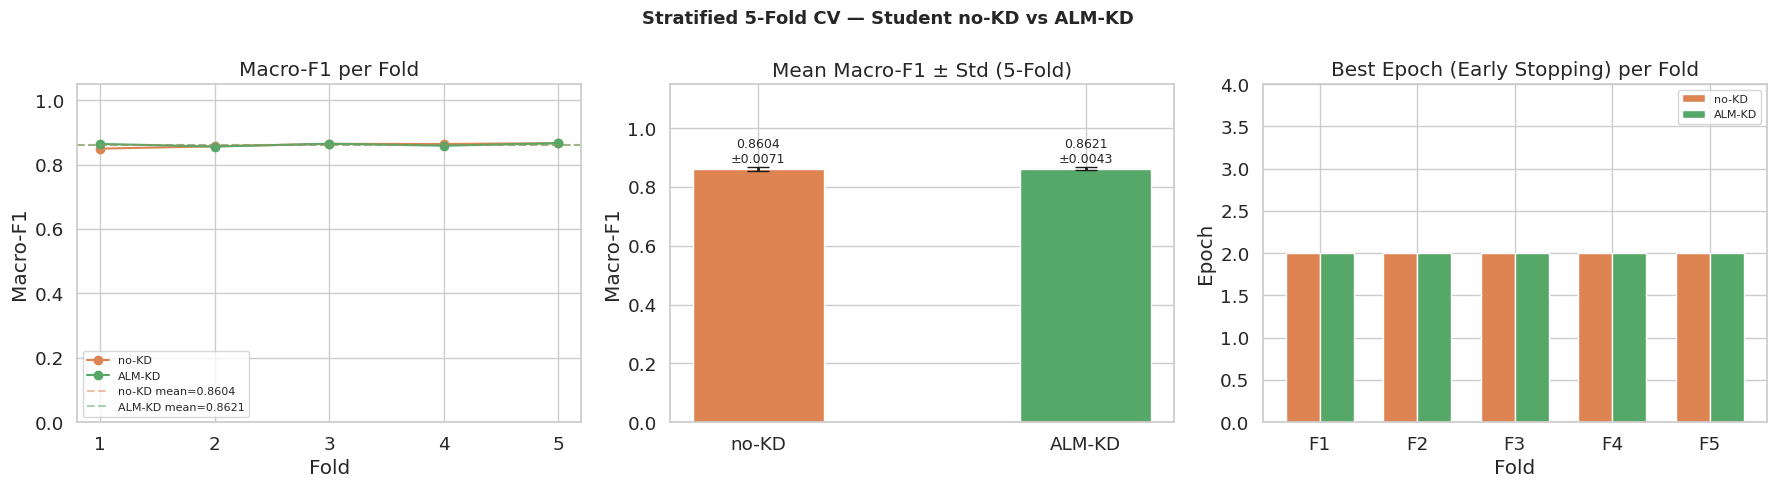

✓ CV visualization saved.


In [26]:
# Cell CV-2: Cross-Validation Visualization
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Stratified {N_FOLDS}-Fold CV — Student no-KD vs ALM-KD",
             fontsize=13, fontweight="bold")

folds = df_cv_no_kd["fold"].tolist()

# Plot 1: Macro-F1 per fold
ax = axes[0]
ax.plot(folds, df_cv_no_kd["f1_macro"], marker="o", label="no-KD",
        color=COLORS["Student no KD"])
ax.plot(folds, df_cv_kd["f1_macro"], marker="o", label="ALM-KD",
        color=COLORS["Student with KD"])
ax.axhline(df_cv_no_kd["f1_macro"].mean(), ls="--", color=COLORS["Student no KD"],
           alpha=0.5, label=f"no-KD mean={df_cv_no_kd['f1_macro'].mean():.4f}")
ax.axhline(df_cv_kd["f1_macro"].mean(), ls="--", color=COLORS["Student with KD"],
           alpha=0.5, label=f"ALM-KD mean={df_cv_kd['f1_macro'].mean():.4f}")
ax.set_title("Macro-F1 per Fold"); ax.set_xlabel("Fold"); ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1.05); ax.set_xticks(folds); ax.legend(fontsize=8)

# Plot 2: Mean ± Std bar chart
ax2 = axes[1]
_models = ["no-KD", "ALM-KD"]
_means  = [df_cv_no_kd["f1_macro"].mean(), df_cv_kd["f1_macro"].mean()]
_stds   = [df_cv_no_kd["f1_macro"].std(),  df_cv_kd["f1_macro"].std()]
_cols   = [COLORS["Student no KD"], COLORS["Student with KD"]]
_bars   = ax2.bar(_models, _means, yerr=_stds, capsize=8, color=_cols,
                  edgecolor="white", width=0.4, error_kw={"linewidth": 2})
for bar, m, s in zip(_bars, _means, _stds):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.005,
             f"{m:.4f}\n±{s:.4f}", ha="center", va="bottom", fontsize=9)
ax2.set_title(f"Mean Macro-F1 ± Std ({N_FOLDS}-Fold)")
ax2.set_ylabel("Macro-F1"); ax2.set_ylim(0, 1.15)

# Plot 3: Best epoch distribution per fold
ax3 = axes[2]
w = 0.35
x = np.arange(len(folds))
ax3.bar(x - w/2, df_cv_no_kd["best_epoch"], width=w, label="no-KD",
        color=COLORS["Student no KD"], edgecolor="white")
ax3.bar(x + w/2, df_cv_kd["best_epoch"],    width=w, label="ALM-KD",
        color=COLORS["Student with KD"], edgecolor="white")
ax3.set_title("Best Epoch (Early Stopping) per Fold")
ax3.set_xlabel("Fold"); ax3.set_ylabel("Epoch")
ax3.set_xticks(x); ax3.set_xticklabels([f"F{f}" for f in folds])
ax3.set_ylim(0, CV_NUM_EPOCHS + 1); ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cv_results_alm_kd.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ CV visualization saved.")


In [27]:
# Cell 25: Self-distillation (conditional — only runs if teacher F1 < threshold)
# ─────────────────────────────────────────────────────────────────────────────
sd_results = None
sd_trainer  = None

if teacher_results["eval_f1"] < TEACHER_F1_THRESHOLD:
    print(f"Teacher F1 {teacher_results['eval_f1']:.4f} < {TEACHER_F1_THRESHOLD} "
          "→ running self-distillation\n")

    frozen_snapshot    = copy.deepcopy(teacher_model)
    self_distill_model = AutoModelForSequenceClassification.from_pretrained(
        TEACHER_NAME,
        num_labels=num_labels, id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    sd_trainer = SelfDistillTrainer(
        frozen_teacher   = frozen_snapshot,
        model            = self_distill_model,
        args             = make_training_args(os.path.join(OUTPUT_DIR, "ckpt-sd"), TEACHER_LR),
        train_dataset    = teacher_datasets["train"],
        eval_dataset     = teacher_datasets["validation"],
        processing_class = teacher_tokenizer,
        data_collator    = DataCollatorWithPadding(teacher_tokenizer),
        compute_metrics  = compute_metrics,
        callbacks        = [sd_cb, EarlyStoppingCallback(EARLY_STOPPING_PATIENCE)],
    )
    sd_trainer.train()
    sd_results = sd_trainer.evaluate(teacher_datasets["test"])

    print(f"\nOriginal teacher F1       : {teacher_results['eval_f1']:.4f}")
    print(f"Self-distilled teacher F1 : {sd_results['eval_f1']:.4f}")
    print(f"Gain                      : {sd_results['eval_f1'] - teacher_results['eval_f1']:+.4f}")

    if sd_results["eval_f1"] > teacher_results["eval_f1"]:
        print("Self-distilled teacher is better → promoting to final teacher.")
        teacher_model   = self_distill_model
        teacher_results = sd_results
    else:
        print("Original teacher is still better → keeping it.")
else:
    print(f"Teacher F1 {teacher_results['eval_f1']:.4f} ≥ {TEACHER_F1_THRESHOLD} "
          "→ self-distillation skipped.")

print(f"\nFinal teacher F1 : {teacher_results['eval_f1']:.4f}")


Teacher F1 0.8697 ≥ 0.8 → self-distillation skipped.

Final teacher F1 : 0.8697


In [28]:
# Cell 26: Train student baseline — no Knowledge Distillation
# ─────────────────────────────────────────────────────────────────────────────
student_no_kd = AutoModelForSequenceClassification.from_pretrained(
    STUDENT_NAME,
    num_labels=num_labels, id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True,
)

student_no_kd_trainer = Trainer(
    model            = student_no_kd,
    args             = make_training_args(os.path.join(OUTPUT_DIR, "ckpt-student-no-kd"), STUDENT_LR),
    train_dataset    = student_datasets["train"],
    eval_dataset     = student_datasets["validation"],
    processing_class = student_tokenizer,
    data_collator    = DataCollatorWithPadding(student_tokenizer),
    compute_metrics  = compute_metrics,
    callbacks        = [no_kd_cb, EarlyStoppingCallback(EARLY_STOPPING_PATIENCE)],
)

student_no_kd_trainer.train()
no_kd_results = student_no_kd_trainer.evaluate(student_datasets["test"])

print(f"\nStudent (no KD)  —  Test F1   : {no_kd_results['eval_f1']:.4f}")
print(f"Student (no KD)  —  Test Loss : {no_kd_results['eval_loss']:.4f}")
print("\nClassification Report (Student — no KD):")
print(no_kd_results.get("eval_report", ""))


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1,Report
1,0.963705,0.894610,0.792141,precision recall f1-score support negative 0.79 0.72 0.75 380 neutral 0.69 0.77 0.73 176 positive 0.88 0.90 0.89 711 accuracy 0.83 1267 macro avg 0.79 0.80 0.79 1267 weighted avg 0.83 0.83 0.83 1267
2,0.635781,0.828768,0.788312,precision recall f1-score support negative 0.84 0.74 0.78 380 neutral 0.76 0.62 0.69 176 positive 0.85 0.94 0.90 711 accuracy 0.84 1267 macro avg 0.82 0.77 0.79 1267 weighted avg 0.83 0.84 0.83 1267
3,0.347490,0.913315,0.807958,precision recall f1-score support negative 0.79 0.81 0.80 380 neutral 0.71 0.72 0.71 176 positive 0.92 0.90 0.91 711 accuracy 0.85 1267 macro avg 0.81 0.81 0.81 1267 weighted avg 0.85 0.85 0.85 1267
4,0.172597,1.104775,0.821151,precision recall f1-score support negative 0.79 0.84 0.82 380 neutral 0.77 0.70 0.73 176 positive 0.91 0.91 0.91 711 accuracy 0.86 1267 macro avg 0.83 0.82 0.82 1267 weighted avg 0.86 0.86 0.86 1267
5,0.107392,1.226185,0.823960,precision recall f1-score support negative 0.81 0.85 0.83 380 neutral 0.77 0.70 0.73 176 positive 0.91 0.91 0.91 711 accuracy 0.86 1267 macro avg 0.83 0.82 0.82 1267 weighted avg 0.86 0.86 0.86 1267


  [Student-no-KD] Epoch  1 | train_loss:  0.9637 | eval_loss:  0.8946 | eval_F1:  0.7921


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [Student-no-KD] Epoch  5 | train_loss:  0.1074 | eval_loss:  1.2262 | eval_F1:  0.8240


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


  [Student-no-KD] Epoch  5 | train_loss:  0.1074 | eval_loss:  1.3147 | eval_F1:  0.8046

Student (no KD)  —  Test F1   : 0.8046
Student (no KD)  —  Test Loss : 1.3147

Classification Report (Student — no KD):
              precision    recall  f1-score   support

    negative       0.79      0.85      0.82       380
     neutral       0.73      0.63      0.68       177
    positive       0.92      0.92      0.92       711

    accuracy                           0.86      1268
   macro avg       0.81      0.80      0.80      1268
weighted avg       0.86      0.86      0.85      1268



In [29]:
# Cell 27: Train student with ALM-KD
# ─────────────────────────────────────────────────────────────────────────────

# ── FIX: Unwrap DataParallel and force single-GPU before KD training ──────────
import gc

def unwrap_and_pin(model, device="cuda:0"):
    if hasattr(model, "module"):
        model = model.module
    return model.to(device)

teacher_model = unwrap_and_pin(teacher_model.eval())

gc.collect()
torch.cuda.empty_cache()

for i in range(torch.cuda.device_count()):
    alloc  = torch.cuda.memory_allocated(i) / 1e9
    reserv = torch.cuda.memory_reserved(i) / 1e9
    print(f"GPU {i}: allocated={alloc:.2f}GB  reserved={reserv:.2f}GB")

# ── Dataset setup ─────────────────────────────────────────────────────────────
kd_datasets.set_format(
    type="torch",
    columns=[
        "label", "input_ids", "attention_mask",
        "teacher_input_ids", "teacher_attention_mask", "teacher_token_type_ids",
    ],
)
kd_train_dataset = kd_datasets["train"]
kd_valid_dataset = kd_datasets["validation"]
kd_test_dataset  = kd_datasets["test"]

assert "teacher_input_ids" in kd_train_dataset.column_names, \
    "teacher_input_ids missing — re-run Cell 14."
print(f"\n✓ KD dataset columns: {kd_train_dataset.column_names}")

# ── OOM fix: halve batch size + disable attention transfer ────────────────────
_TRAIN_BATCH_SIZE          = 16    # was 32
_GRAD_ACCUMULATION_STEPS   = 2     # effective batch = 16 * 2 = 32 (sama kayak semula)
_ALM_ETA                   = 0.0   # disable attention maps — most memory-hungry

# ── Load fresh student model pinned to cuda:0 ─────────────────────────────────
student_with_kd = AutoModelForSequenceClassification.from_pretrained(
    STUDENT_NAME,
    num_labels=num_labels, id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True,
).to("cuda:0")

# ── FIX 3: Enable gradient checkpointing on student ──────────────────────────
# Trade-off: sedikit lebih lambat (~20%) tapi VRAM turun signifikan
# karena intermediate activations tidak disimpan semua di memory
student_with_kd.gradient_checkpointing_enable()
print("✓ Gradient checkpointing enabled on student model.")

# ── TrainingArguments: single-GPU ─────────────────────────────────────────────
def make_kd_training_args(output_dir: str, lr: float) -> TrainingArguments:
    return TrainingArguments(
        output_dir                  = output_dir,
        num_train_epochs            = NUM_EPOCHS,
        per_device_train_batch_size = _TRAIN_BATCH_SIZE,
        per_device_eval_batch_size  = EVAL_BATCH_SIZE,
        gradient_accumulation_steps = _GRAD_ACCUMULATION_STEPS,  # effective batch tetap 32
        learning_rate               = lr,
        weight_decay                = WEIGHT_DECAY,
        warmup_ratio                = WARMUP_RATIO,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "eval_f1",
        greater_is_better           = True,
        save_total_limit            = 2,
        logging_steps               = 50,
        report_to                   = "none",
        fp16                        = False,
        gradient_checkpointing      = True,                       # trade compute for VRAM
        remove_unused_columns       = False,
        dataloader_pin_memory       = False,
        local_rank                  = -1,
    )

# ── Fresh callback ────────────────────────────────────────────────────────────
kd_cb = MetricsLoggerCallback("Student-with-KD")

# ── Build ALMKDTrainer ────────────────────────────────────────────────────────
kd_trainer = ALMKDTrainer(
    teacher_model     = teacher_model,
    model             = student_with_kd,
    args              = make_kd_training_args(
                            os.path.join(OUTPUT_DIR, "ckpt-student-alm-kd"),
                            STUDENT_LR,
                        ),
    alpha             = ALM_ALPHA,
    alpha_end         = ALM_ALPHA_END,
    beta              = ALM_BETA,
    delta             = ALM_DELTA,
    eta               = _ALM_ETA,
    temperature       = ALM_TEMPERATURE,
    gamma             = ALM_GAMMA,
    use_dynamic_alpha = USE_DYNAMIC_ALPHA,
    label_smoothing   = LABEL_SMOOTHING,
    class_weights     = CLASS_WEIGHTS,
    train_dataset     = kd_train_dataset,
    eval_dataset      = kd_valid_dataset,
    processing_class  = student_tokenizer,
    data_collator     = KDDataCollator(
                            student_tokenizer=student_tokenizer,
                            teacher_tokenizer=teacher_tokenizer,
                        ),
    compute_metrics   = compute_metrics,
    callbacks         = [kd_cb, EarlyStoppingCallback(EARLY_STOPPING_PATIENCE)],
)

print("Starting ALM-KD training ...")
print(f"  CE + KL(α={ALM_ALPHA}→{ALM_ALPHA_END}) + CLS(β={ALM_BETA})"
      f" + PKD(δ={ALM_DELTA}) + Attn(η={_ALM_ETA})  [attention disabled]")
print(f"  batch_size={_TRAIN_BATCH_SIZE} x grad_accum={_GRAD_ACCUMULATION_STEPS}"
      f" (effective={_TRAIN_BATCH_SIZE * _GRAD_ACCUMULATION_STEPS})"
      f"  label_smoothing={LABEL_SMOOTHING}"
      f"  weight_decay={WEIGHT_DECAY}\n")

kd_trainer.train()

GPU 0: allocated=3.16GB  reserved=3.48GB
GPU 1: allocated=0.02GB  reserved=0.04GB

✓ KD dataset columns: ['label', 'input_ids', 'attention_mask', 'teacher_input_ids', 'teacher_attention_mask', 'teacher_token_type_ids']


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ Gradient checkpointing enabled on student model.
Starting ALM-KD training ...
  CE + KL(α=0.5→0.2) + CLS(β=0.2) + PKD(δ=0.1) + Attn(η=0.0)  [attention disabled]
  batch_size=16 x grad_accum=2 (effective=32)  label_smoothing=0.1  weight_decay=0.01

  [ALMKDTrainer] Epoch 1 | α = 0.5000


Epoch,Training Loss,Validation Loss,F1,Report
1,3.062800,0.962097,0.769523,precision recall f1-score support negative 0.74 0.71 0.73 380 neutral 0.69 0.71 0.70 176 positive 0.88 0.89 0.88 711 accuracy 0.81 1267 macro avg 0.77 0.77 0.77 1267 weighted avg 0.81 0.81 0.81 1267
2,2.055393,1.031333,0.782485,precision recall f1-score support negative 0.82 0.71 0.76 380 neutral 0.62 0.76 0.69 176 positive 0.90 0.91 0.90 711 accuracy 0.83 1267 macro avg 0.78 0.79 0.78 1267 weighted avg 0.83 0.83 0.83 1267
3,1.422258,0.985347,0.812921,precision recall f1-score support negative 0.76 0.85 0.80 380 neutral 0.69 0.77 0.73 176 positive 0.95 0.87 0.91 711 accuracy 0.85 1267 macro avg 0.80 0.83 0.81 1267 weighted avg 0.86 0.85 0.85 1267
4,1.162082,1.001405,0.811386,precision recall f1-score support negative 0.78 0.84 0.81 380 neutral 0.73 0.70 0.71 176 positive 0.93 0.90 0.91 711 accuracy 0.85 1267 macro avg 0.81 0.81 0.81 1267 weighted avg 0.86 0.85 0.85 1267
5,0.977462,0.939885,0.805697,precision recall f1-score support negative 0.77 0.84 0.80 380 neutral 0.77 0.66 0.71 176 positive 0.91 0.90 0.91 711 accuracy 0.85 1267 macro avg 0.82 0.80 0.81 1267 weighted avg 0.85 0.85 0.85 1267


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [ALMKDTrainer] Epoch 5 | α = 0.2000
  [Student-with-KD] Epoch  5 | train_loss:  0.9775 | eval_loss:  0.9399 | eval_F1:  0.8057


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=920, training_loss=1.8945529813351838, metrics={'train_runtime': 814.5966, 'train_samples_per_second': 72.226, 'train_steps_per_second': 1.129, 'total_flos': 1523853935244180.0, 'train_loss': 1.8945529813351838, 'epoch': 5.0})

In [30]:
# Cell 28: Evaluate ALM-KD student and summarize all results
# ─────────────────────────────────────────────────────────────────────────────
kd_results = kd_trainer.evaluate(kd_test_dataset)
print(f"Student (ALM-KD)  —  Test F1   : {kd_results['eval_f1']:.4f}")
print(f"Student (ALM-KD)  —  Test Loss : {kd_results['eval_loss']:.4f}")
print("\nClassification Report (Student — ALM-KD):")
print(kd_results.get("eval_report", ""))

rows = [
    ("Teacher (IndoBERT)",               teacher_results["eval_f1"], teacher_results["eval_loss"]),
    ("Student no KD (mDistilBERT)",      no_kd_results["eval_f1"],  no_kd_results["eval_loss"]),
    ("Student ALM-KD (mDistilBERT)",     kd_results["eval_f1"],     kd_results["eval_loss"]),
]
if sd_results is not None:
    rows.insert(1, ("Self-Distilled Teacher", sd_results["eval_f1"], sd_results["eval_loss"]))

df_summary = pd.DataFrame(rows, columns=["Model", "Test F1", "Test Loss"])
df_summary["KD Gain vs no-KD"] = df_summary["Test F1"].apply(   # ← fix: "Val F1" → "Test F1"
    lambda x: f"{x - no_kd_results['eval_f1']:+.4f}"
)

print("\n" + "=" * 66)
print("                 EXPERIMENT RESULTS SUMMARY")
print("=" * 66)
print(df_summary.to_string(index=False))
print("=" * 66)
print(f"\nALM-KD gain over no-KD baseline : {kd_results['eval_f1'] - no_kd_results['eval_f1']:+.4f}")
print(f"Gap to final teacher            : {teacher_results['eval_f1'] - kd_results['eval_f1']:+.4f}")

  [Student-with-KD] Epoch  5 | train_loss:  0.9775 | eval_loss:  1.0538 | eval_F1:  0.7775
Student (ALM-KD)  —  Test F1   : 0.7775
Student (ALM-KD)  —  Test Loss : 1.0538

Classification Report (Student — ALM-KD):
              precision    recall  f1-score   support

    negative       0.71      0.86      0.78       380
     neutral       0.66      0.67      0.66       177
    positive       0.95      0.84      0.89       711

    accuracy                           0.82      1268
   macro avg       0.77      0.79      0.78      1268
weighted avg       0.84      0.82      0.83      1268


                 EXPERIMENT RESULTS SUMMARY
                       Model  Test F1  Test Loss KD Gain vs no-KD
          Teacher (IndoBERT) 0.869695   1.127102          +0.0651
 Student no KD (mDistilBERT) 0.804618   1.314712          +0.0000
Student ALM-KD (mDistilBERT) 0.777527   1.053792          -0.0271

ALM-KD gain over no-KD baseline : -0.0271
Gap to final teacher            : +0.0922


In [31]:
# Cell 29: Prediction helpers
# ─────────────────────────────────────────────────────────────────────────────
def get_flat_predictions(trainer: Trainer, dataset) -> tuple:
    out       = trainer.predict(dataset)
    preds     = np.argmax(out.predictions, axis=-1)
    true_flat = [id2label[int(l)] for l in out.label_ids]
    pred_flat = [id2label[int(p)] for p in preds]
    return true_flat, pred_flat


def get_per_class_f1(trainer: Trainer, dataset) -> dict:
    true, pred = get_flat_predictions(trainer, dataset)
    report     = classification_report(
        true, pred, target_names=all_labels, output_dict=True, zero_division=0,
    )
    return {cls: report[cls]["f1-score"] for cls in all_labels}


print("✓ Prediction helpers ready.")


✓ Prediction helpers ready.


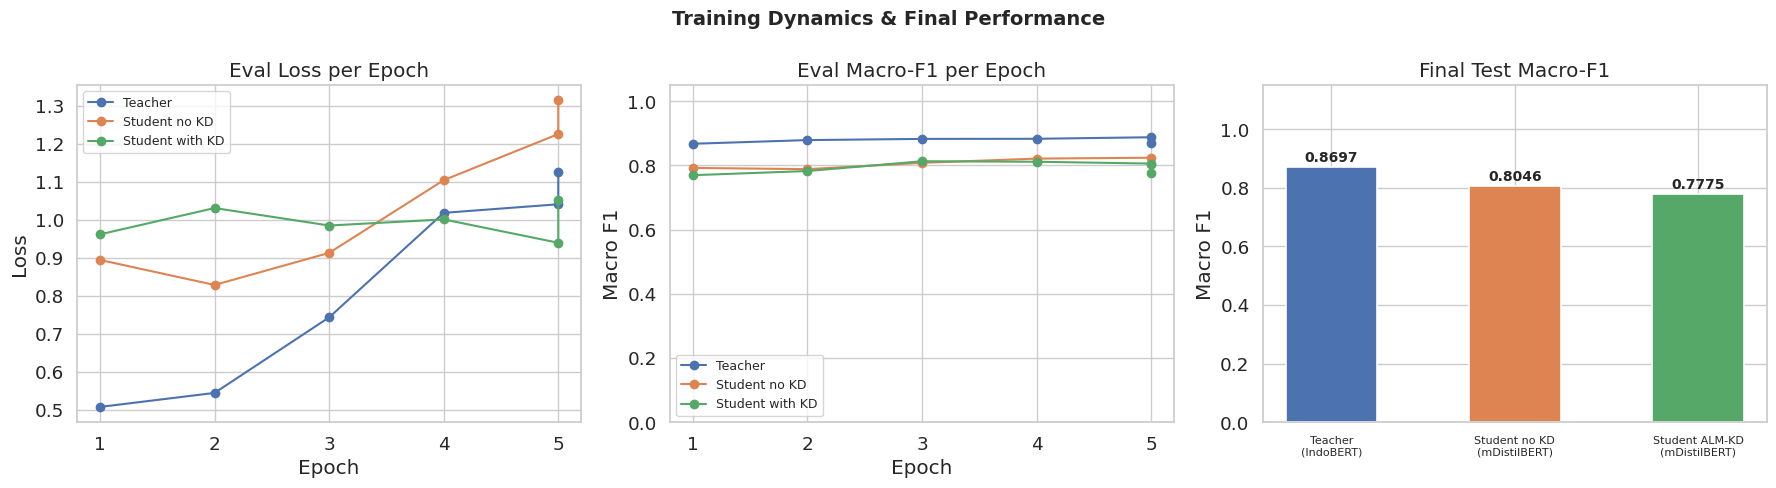

Saved: training_overview.png


In [32]:
# Cell 30: Training dynamics plots
# ─────────────────────────────────────────────────────────────────────────────
callbacks_to_plot = {
    "Teacher":         teacher_cb,
    "Student no KD":   no_kd_cb,
    "Student with KD": kd_cb,
}
if sd_results is not None:
    callbacks_to_plot["Self-Distilled Teacher"] = sd_cb

COLOR_MAP = {
    "Teacher":                         COLORS["Teacher"],
    "Self-Distilled Teacher":          COLORS["Self-Distilled Teacher"],
    "Student no KD":                   COLORS["Student no KD"],
    "Student with KD":                 COLORS["Student with KD"],
    "Teacher (IndoBERT)":              COLORS["Teacher"],
    "Student no KD (mDistilBERT)":     COLORS["Student no KD"],
    "Student ALM-KD (mDistilBERT)":    COLORS["Student with KD"],
    "Self-Distilled Teacher":          COLORS["Self-Distilled Teacher"],
}

fig = plt.figure(figsize=(18, 5))
fig.suptitle("Training Dynamics & Final Performance", fontsize=14, fontweight="bold")

ax1 = fig.add_subplot(1, 3, 1)
for lbl, cb in callbacks_to_plot.items():
    ax1.plot(cb.history["epoch"], cb.history["eval_loss"],
             marker="o", label=lbl, color=COLOR_MAP.get(lbl, "#999"))
ax1.set_title("Eval Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax2 = fig.add_subplot(1, 3, 2)
for lbl, cb in callbacks_to_plot.items():
    ax2.plot(cb.history["epoch"], cb.history["eval_f1"],
             marker="o", label=lbl, color=COLOR_MAP.get(lbl, "#999"))
ax2.set_title("Eval Macro-F1 per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro F1")
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax3 = fig.add_subplot(1, 3, 3)
bar_labels = [r[0] for r in rows]
bar_f1s    = [r[1] for r in rows]
bar_colors = [COLOR_MAP.get(l, "#999") for l in bar_labels]
bars = ax3.bar(range(len(bar_labels)), bar_f1s, color=bar_colors,
               edgecolor="white", linewidth=1.2, width=0.5)
for bar, val in zip(bars, bar_f1s):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax3.set_xticks(range(len(bar_labels)))
ax3.set_xticklabels([l.replace(" (", "\n(") for l in bar_labels], fontsize=8)
ax3.set_ylim(0, 1.15)
ax3.set_ylabel("Macro F1")
ax3.set_title("Final Test Macro-F1")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_overview.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_overview.png")


Map:   0%|          | 0/1268 [00:00<?, ? examples/s]

Map:   0%|          | 0/1268 [00:00<?, ? examples/s]


────────────────────────────────────────────────────────────
Model        : Teacher (IndoBERT)
  Macro-F1   : 0.8697
  Weighted-F1: 0.9056

              precision    recall  f1-score   support

    negative     0.8658    0.9000    0.8826       380
     neutral     0.8098    0.7458    0.7765       177
    positive     0.9507    0.9494    0.9500       711

    accuracy                         0.9062      1268
   macro avg     0.8754    0.8650    0.8697      1268
weighted avg     0.9056    0.9062    0.9056      1268



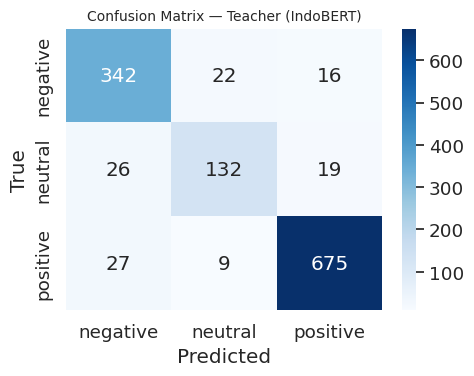

Saved: cm_teacher_(indobert).png

────────────────────────────────────────────────────────────
Model        : Student (no KD)
  Macro-F1   : 0.8046
  Weighted-F1: 0.8546

              precision    recall  f1-score   support

    negative     0.7873    0.8474    0.8162       380
     neutral     0.7320    0.6328    0.6788       177
    positive     0.9221    0.9156    0.9188       711

    accuracy                         0.8557      1268
   macro avg     0.8138    0.7986    0.8046      1268
weighted avg     0.8552    0.8557    0.8546      1268



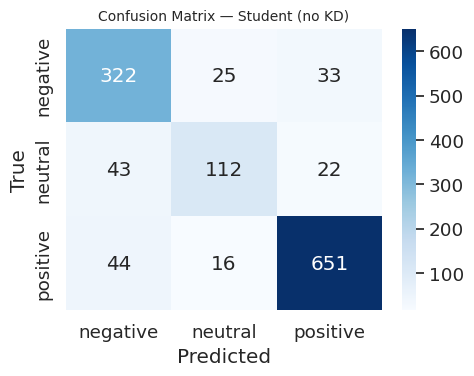

Saved: cm_student_(no_kd).png

────────────────────────────────────────────────────────────
Model        : Student (ALM-KD)
  Macro-F1   : 0.7775
  Weighted-F1: 0.8265

              precision    recall  f1-score   support

    negative     0.7093    0.8605    0.7776       380
     neutral     0.6556    0.6667    0.6611       177
    positive     0.9537    0.8411    0.8939       711

    accuracy                         0.8226      1268
   macro avg     0.7729    0.7894    0.7775      1268
weighted avg     0.8389    0.8226    0.8265      1268



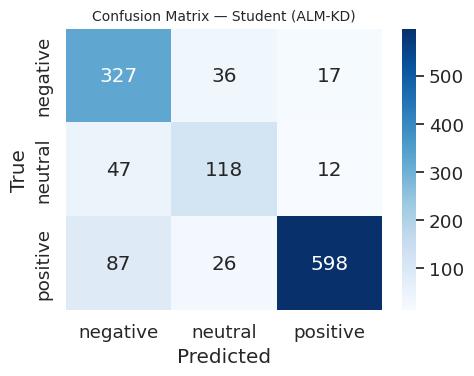

Saved: cm_student_(alm-kd).png

TEST SET COMPARISON
             Model Macro-F1 Weighted-F1
Teacher (IndoBERT)   0.8697      0.9056
   Student (no KD)   0.8046      0.8546
  Student (ALM-KD)   0.7775      0.8265


In [33]:
LABEL_NAMES = [id2label[i] for i in range(num_labels)]
EVAL_DEVICE = torch.device("cuda:0")


def predict_manual(model, dataset, collator, batch_size=32) -> tuple:
    """Manual inference loop — bypass Trainer sepenuhnya, no DataParallel."""
    # Unwrap kalau masih wrapped DataParallel
    raw = model.module if hasattr(model, "module") else model
    raw = raw.to(EVAL_DEVICE).eval()

    from torch.utils.data import DataLoader
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=collator)

    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            labels = batch.pop("labels", None)
            # Hanya kirim keys yang diterima model
            import inspect
            accepted = set(inspect.signature(raw.forward).parameters)
            batch = {k: v.to(EVAL_DEVICE) for k, v in batch.items() if k in accepted}
            out = raw(**batch)
            all_logits.append(out.logits.cpu())
            if labels is not None:
                all_labels.append(labels.cpu())

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy() if all_labels else None
    return logits, labels


def evaluate_on_test(model, collator, test_ds, model_name: str) -> dict:
    logits, true_ids = predict_manual(model, test_ds, collator)
    pred_ids    = np.argmax(logits, axis=-1)
    f1_macro    = sk_f1(true_ids, pred_ids, average="macro")
    f1_weighted = sk_f1(true_ids, pred_ids, average="weighted")

    print(f"\n{'─' * 60}")
    print(f"Model        : {model_name}")
    print(f"  Macro-F1   : {f1_macro:.4f}")
    print(f"  Weighted-F1: {f1_weighted:.4f}")
    print()
    print(classification_report(true_ids, pred_ids, target_names=LABEL_NAMES, digits=4))

    cm = confusion_matrix(true_ids, pred_ids)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    fname = f"cm_{model_name.lower().replace(' ', '_').replace('/', '-')}.png"
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=100)
    plt.show()
    print(f"Saved: {fname}")
    return {"model": model_name, "macro_f1": f1_macro, "weighted_f1": f1_weighted}


# Re-tokenise test set
t_test = raw_datasets["test"].map(
    lambda ex: teacher_tokenizer(ex["text"], truncation=True,
                                 max_length=MAX_LENGTH, padding=False),
    batched=True,
    remove_columns=[c for c in ["text", "raw_text"] if c in raw_datasets["test"].column_names],
)
s_test = raw_datasets["test"].map(
    lambda ex: student_tokenizer(ex["text"], truncation=True,
                                 max_length=MAX_LENGTH, padding=False),
    batched=True,
    remove_columns=[c for c in ["text", "raw_text"] if c in raw_datasets["test"].column_names],
)
t_test.set_format("torch")
s_test.set_format("torch")

t_coll = DataCollatorWithPadding(teacher_tokenizer)
s_coll = DataCollatorWithPadding(student_tokenizer)

test_results_all = []

# 1. Teacher
test_results_all.append(
    evaluate_on_test(teacher_model, t_coll, t_test, "Teacher (IndoBERT)")
)

# 2. Self-distilled teacher (kalau ada)
if sd_results is not None and sd_trainer is not None:
    test_results_all.append(
        evaluate_on_test(sd_trainer.model, t_coll, t_test, "Teacher Self-Distilled")
    )

# 3. Student no KD
test_results_all.append(
    evaluate_on_test(student_no_kd, s_coll, s_test, "Student (no KD)")
)

# 4. Student ALM-KD — pakai s_test bukan kd_test_dataset
# (kd_test_dataset punya teacher columns yang tidak dibutuhkan untuk inference)
test_results_all.append(
    evaluate_on_test(student_with_kd, s_coll, s_test, "Student (ALM-KD)")
)

# Summary
print("\n" + "=" * 62)
print("TEST SET COMPARISON")
print("=" * 62)
df_test_cmp = pd.DataFrame([
    {"Model": r["model"], "Macro-F1": f"{r['macro_f1']:.4f}",
     "Weighted-F1": f"{r['weighted_f1']:.4f}"}
    for r in test_results_all
])
print(df_test_cmp.to_string(index=False))

In [34]:
# Cell 32: Save all models, tokenizers, and results CSV
# ─────────────────────────────────────────────────────────────────────────────
models_to_save = [
    ("teacher",             teacher_model,   teacher_tokenizer),
    ("student-no-kd",       student_no_kd,   student_tokenizer),
    ("student-with-alm-kd", student_with_kd, student_tokenizer),
]
if sd_results is not None and sd_trainer is not None:
    models_to_save.insert(1, ("teacher-self-distilled", sd_trainer.model, teacher_tokenizer))

for name, mdl, tok in models_to_save:
    path = os.path.join(OUTPUT_DIR, name)
    os.makedirs(path, exist_ok=True)
    mdl.save_pretrained(path)
    tok.save_pretrained(path)
    print(f"Saved : {path}")

csv_path = os.path.join(OUTPUT_DIR, "results_summary.csv")
df_summary.to_csv(csv_path, index=False)
print(f"\nResults CSV : {csv_path}")
print(f"All outputs → {OUTPUT_DIR}")
print("\n✓ Done!")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved : /kaggle/working/teacher


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved : /kaggle/working/student-no-kd


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved : /kaggle/working/student-with-alm-kd

Results CSV : /kaggle/working/results_summary.csv
All outputs → /kaggle/working

✓ Done!
